# PROJET STOCK MARKET - PREDICTION DE EARNINGS


# Introduction

L'objectif de ce notebook est d'évaluer le meilleur modèle d'apprentissage supervisé pour la prédiction des earnings du S&P 500. Pour cela, nous allons explorer plusieurs architectures étudiées dans le cours de modélisation statistique, à savoir la régression linéaire simple et la régression linéaire multiple.
Ensuite, nous développerons deux modèles de deep learning : un réseau neuronal simple et un réseau basé sur des couches LSTM.
Enfin, nous analyserons comment les données réagissent à ces modèles à l'aide de visualisations et de métriques telles que le MAE et la fonction de perte (loss).

# 1. Outils

Cette partie présente les outils nécessaires à notre étude, notamment les librairies utilisées, les paramètres ainsi que les fonctions. Ensuite, les données sont importées depuis notre base de données SQL fournie sur notre GitHub.

## 1.1 Librairies 

In [69]:

import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import mysql.connector
from outils.import_bdd import *
from outils.data_windowing import WindowGenerator
import tomllib

import tensorflow as tf
from tensorflow.keras.callbacks import EarlyStopping


from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import LabelEncoder, LabelBinarizer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, log_loss
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from bertopic import BERTopic
from sklearn.feature_extraction.text import CountVectorizer

import re 


## 1.2 Parametres

In [5]:
with open("outils/config.toml", "rb") as f:
    config = tomllib.load(f)

parametres = config["parametre"]

SEED = parametres["seed"]
INPUT_WIDTH = parametres["input_width"]
LABEL_WIDTH = parametres["label_width"]
SHIFT = parametres["shift"]
P_VAL = parametres["p_val"]
P_TEST = parametres["p_test"]
EPOCHS = parametres["epochs"]
BATCH_SIZE = parametres["batch_size"]
FIGSIZE = tuple(parametres["fig_size"])

np.random.seed(SEED)
tf.random.set_seed(SEED)


## 1.3 Connexion a la base de donnees

In [6]:

bdd = mysql.connector.connect(**config["bdd"])


## 1.4 Fonctions

In [7]:

df = import_sp500_table_prediction(bdd)

MEAN_EARNINGS = df["earnings"].mean()
STD_EARNINGS = df["earnings"].std()
    
def plot_prediction(wg: WindowGenerator, model: tf.keras.Sequential,
                    mean: float = MEAN_EARNINGS, std: float = STD_EARNINGS):

    plt.figure(figsize=FIGSIZE)
 
    y_pred = model.predict(wg.training_input).flatten()
    y_pred = (y_pred + mean) * std  

   
    y_real = wg.training_label.flatten()
    y_real = (y_real + mean) * std  

    plt.plot(y_pred, label="Predicted")
    plt.plot(y_real, label="Real")
    plt.legend()
    plt.show()

def plot_prediction_test(wg: WindowGenerator, model: tf.keras.Sequential,
                    mean: float = MEAN_EARNINGS, std: float = STD_EARNINGS):

    plt.figure(figsize=FIGSIZE)
 
    y_pred = model.predict(wg.test_input).flatten()
    y_pred = (y_pred + mean) * std  

   
    y_real = wg.test_label.flatten()
    y_real = (y_real + mean) * std  

    plt.plot(y_pred, label="Predicted")
    plt.plot(y_real, label="Real")
    plt.legend()
    plt.show()

def plot_prediction_test_general(wg: WindowGenerator, model: tf.keras.Sequential,label_encoder:int = None,
                    mean: float = MEAN_EARNINGS, std: float = STD_EARNINGS):
    
    if label_encoder is not None:
        x,y = wg.split(wg.raw_df.to_numpy(),wg.input_width,wg.shift,wg.label_width,2)
    else:
        x,y = wg.split(wg.raw_df.to_numpy(),wg.input_width,wg.shift,wg.label_width)

    plt.figure(figsize=FIGSIZE)

    y_pred = model.predict(x).flatten()
    y_pred = (y_pred + mean) * std  

    y_real = y.flatten()
    y_real = (y_real + mean) * std  

    plt.plot(y_pred, label="Predicted")
    plt.plot(y_real, label="Real")
    plt.legend()
    plt.show()


def plot_bar_metrics(metrics:str,models:dict,title:str = None):
    plt.figure(figsize=(15,15))
    height = []
    for keys in models.keys():
        if keys != "Baseline":
            height.append(models[keys].history[metrics][-1])
        else:
            height.append(models[keys][metrics])
    plt.bar(models.keys(),height)

    if title: 
        plt.title(title)
    else:
        plt.title(f"{metrics} of models")

    plt.show()

def plot_training_validation(history:dict,metrics:str,title:str = None): 
    plt.figure(figsize=FIGSIZE)

    if metrics == "loss":
        plt.plot(history["val_loss"],label="val loss")
        plt.plot(history["loss"],label = "loss")
    elif metrics == "mae": 
        plt.plot(history["mae_loss"],label="mae loss")
        plt.plot(history["mae"],label = "mae")

    if title:
        plt.title(title)
        
    plt.legend()
    plt.show()

# 2. Modeles 


## 2.1 Pretraitement de données 

Pour réaliser du forecasting, il est nécessaire de traiter les données d’une manière spécifique. Les algorithmes apprennent généralement à l’aide de fenêtres (windows). Une fenêtre consiste à prendre une séquence de données, par exemple les données du S&P 500 du lundi au mardi comme variables d’entrée, et celles du mercredi comme variable cible pour l’entraînement.
Dans cette perspective, on introduit également la notion de shift, qui correspond au décalage temporel entre chaque fenêtre. Dans cette étude, comme nous travaillons avec des modèles de régression linéaire, et par convention, nous utilisons un shift de 1. 

Avant d’effectuer le windowing, nous allons standardiser les données afin de les convertir en z-scores. Le z-score est une mesure qui représente l’écart d’une observation par rapport à la moyenne générale, exprimé en nombre d’écarts-types. Par exemple, une valeur de -1 indique que l’observation se situe un écart-type en dessous de la moyenne (la moyenne étant égale à 0 après standardisation).Cette transformation permet aux algorithmes d’analyser les données sans rencontrer de problèmes d’échelle.

In [8]:
sp = standar_df(df.copy())

target_col = "earnings"



df_model = sp.copy()

df_model




,observation_date,sp500,dividend,earnings,longInterestRate
idSP,,,,,
2,-1.730577,-0.461055,-0.528404,-0.496333,0.367589
3,-1.728653,-0.461074,-0.528404,-0.496333,0.361070
4,-1.726915,-0.460938,-0.528404,-0.496333,0.365416
5,-1.724990,-0.460777,-0.528404,-0.496333,0.365416
6,-1.723128,-0.460629,-0.528404,-0.496333,0.365416
...,...,...,...,...,...
1830,1.723021,4.658198,4.392132,4.579796,-0.399512
1831,1.724945,4.904417,4.404383,4.636586,-0.321281
1832,1.726807,5.105533,4.404383,4.636586,-0.256088


## 2.1.2 Window Generator 

Sur notre GitHub, vous pouvez retrouver la classe WindowGenerator que nous avons développée afin de créer les fenêtres nécessaires à la préparation des données.
Nous définissons trois objets WindowGenerator. Un pour les modèles régression linéaire multiple et les réseaux de neurones dense, pour lesquels les données doivent être présentées sous forme de matrices 2D (observations × variables), un autre pour le modèle LSTM, qui nécessite des données sous forme de tenseurs 3D (observations × pas de temps × variables).
Cette distinction est essentielle, car les modèles séquentiels comme les LSTM exploitent explicitement la dimension temporelle, contrairement aux modèles linéaires et aux réseaux dense. Pour finir, un pour la régression linéaire simple avec une seule variable .

In [9]:
target_index = df_model.columns.get_loc(target_col)

wg_lstm = WindowGenerator(
    df=df_model,
    input_width=INPUT_WIDTH,
    shift=SHIFT,
    p_val_df=P_VAL,
    p_test_df=P_TEST,
    label_width=LABEL_WIDTH,
    label_encoder= target_index
)

wg_linear = WindowGenerator(
    df=df_model,
    input_width=1,
    shift=1,
    p_val_df=P_VAL,
    p_test_df=P_TEST,
    label_width=1,
    label_encoder= target_index
)

wg_linear_uni_variable = WindowGenerator(
    df=df_model["earnings"],
    input_width=1,
    shift=1,
    p_val_df=P_VAL,
    p_test_df=P_TEST,
    label_width=1,
)



In [10]:

print(wg_linear.training_label.shape)
print(wg_linear.training_input.shape)

(1464,)
(1464, 5)


In [11]:
print(wg_lstm.training_label.flatten().shape)
print(wg_lstm.training_input.shape)

(1460,)
(1460, 5, 5)


# 3. Modeles

## 3.1 Baseline

Afin d’évaluer si notre modèle a correctement appris à partir des données d’entraînement, nous avons défini un baseline predictor. Il s’agit d’un modèle naïf pour lequel la prédiction à l’instant 𝑡+1t+1 est simplement égale à la valeur observée à l’instant t.


In [12]:


class BaselinePredictor:

    def __init__(self, shift: int = 1, target_index: int = 0):
        self.shift = shift
        self.target_index = target_index

    def fit(self, X: np.ndarray, y: np.ndarray):
        
        self.X_train_ = X
        self.y_train_ = y
    
        if self.shift == 1:
            y_pred = X[-1,self.target_index]
        else:
            y_pred = X[-self.shift, self.target_index]

        y_pred = y_pred.reshape(-1)
        y_true = y.flatten()

        loss = np.mean((y_true - y_pred) ** 2)
        mae = np.mean(np.abs(y_true - y_pred))

        self.history = {'loss': loss, 'mae': mae}

        return self.history


    def predict(self, X: np.ndarray) -> np.ndarray:
        if self.shift == 1:
            y_pred = X[-1, self.target_index]
        else:
            y_pred = X[-self.shift, self.target_index]

 
        return y_pred
        






## 3.2 Modèles d’apprentissage supervisé

Le premier modèle est la régression linéaire. Pour la régression linéaire simple ou multiple avec TensorFlow, la seule chose qui change est l’input, donc il ne faut pas créer plusieurs fonctions.


$$
y = \beta_0 + \beta_1 x + \varepsilon
$$


$$
y = \beta_0 + \beta_1 x_1 + \beta_2 x_2 + \dots + \beta_p x_p + \varepsilon
$$

In [13]:

def build_linear_model(input_shape):
    model = tf.keras.Sequential([
        tf.keras.layers.Input(shape=input_shape),
        tf.keras.layers.Dense(1)
    ])

    model.compile(
        optimizer="adam",
        loss="mse",
        metrics=["mae"]
    )
    return model


Le réseau neuronal reste le modèle de deep learning le plus simple. Dans cette architecture, nous avons choisi une seule couche de 32 neurones avec la fonction d’activation ReLU.

$$
\text{ReLU}(x) =
\begin{cases} 
0 & \text{si } x < 0 \\[2mm]
x & \text{si } x \ge 0
\end{cases}
$$

In [14]:


def build_dense_model(input_shape):
    model = tf.keras.Sequential([
        tf.keras.layers.Input(shape=input_shape),
        tf.keras.layers.Dense(32, activation="relu"),
        tf.keras.layers.Dropout(0.5),
        tf.keras.layers.Dense(1)
    ])

    model.compile(
        optimizer="adam",
        loss="mse",
        metrics=["mae"]
    )
    return model

build_dense_model(wg_linear.training_input.shape[1:]).summary()



Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 32)             │           192 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225 (900.00 B)

 Trainable params: 225 (900.00 B)

 Non-trainable params: 0 (0.00 B)

Pour comprendre les LSTM (Long Short-Term Memory), il s’agit d’un type de réseau de neurones récurrent (RNN, Recurrent Neural Network) conçu pour mieux gérer les dépendances temporelles dans les données.
Dans le cas de la prédiction d’un stock, les données récentes ont généralement plus d’importance que celles d’il y a 50 ans.
L’idée générale d’une LSTM est de posséder un cell state qui agit comme une mémoire, permettant d’agréger et de conserver l’information pertinente sur l’ensemble des séquences temporelles, tout en filtrant ce qui est moins important.

Pour cela, on utilise la fonction tanh, qui permet de normaliser les valeurs du cell state entre -1 et 1. L’objectif est de déterminer si une variable doit être intégrée dans ce cell state : si la valeur est inférieure à 0, elle n’est pas prise en compte.

$$
\tanh(x) = \frac{e^x - e^{-x}}{e^x + e^{-x}}
$$

Pour finir, nous avons utilisé le dropout, une méthode de régularisation permettant d’éviter le overfitting. Le dropout consiste à éliminer aléatoirement une partie des neurones pendant l’entraînement. Ici nous avons appliqué un taux de 10 % aprés chaque LSTM pour favoriser la généralisation du modèle.

In [15]:

def build_lstm_model(input_shape):
        
    model = tf.keras.Sequential([
        tf.keras.layers.Input(shape=input_shape),
        tf.keras.layers.LSTM(16, activation='tanh',return_sequences=True),  
        tf.keras.layers.Dropout(0.1),
        tf.keras.layers.LSTM(16, activation='tanh'), 
        tf.keras.layers.Dropout(0.1), 

        tf.keras.layers.Dense(1)             
    ])

    model.compile(
        optimizer="adam",
        loss="mse",
        metrics=["mae"]
    )
    return model

build_lstm_model(wg_lstm.training_input.shape[1:]).summary()


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 5, 16)          │         1,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 5, 16)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 16)             │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,537 (13.82 KB)

 Trainable params: 3,537 (13.82 KB)

 Non-trainable params: 0 (0.00 B)

## 3.3 Callback

Notre problème principal dans ce notebook est le surapprentissage. Pour l’éviter, il faut faire attention au nombre d’epochs effectuées. Si le MAE de validation commence à augmenter, continuer l’entraînement n’a aucun sens, car cela signifie que le modèle s’adapte trop aux données d’entraînement.
Notre objectif est d’obtenir un MAE de validation qui converge vers celui de l’entraînement. Pour cela, nous avons utilisé un callback. Le callback est une classe qui surveille l’entraînement et peut l’interrompre automatiquement si la perte de validation (val loss) continue d’augmenter après un certain nombre d’itérations.

In [16]:
class StopIfValLossRepeated(tf.keras.callbacks.Callback):

    def __init__(self, max_repeats=3):
        super().__init__()
        self.max_repeats = max_repeats
        self.last_val_loss = None
        self.counter = 0

    def on_epoch_end(self, epoch, logs=None):
        current_val_loss = logs.get("val_loss")

        
        if self.last_val_loss is not None and current_val_loss >= self.last_val_loss:
            self.counter += 1
        else:
            self.counter = 0 

        self.last_val_loss = current_val_loss

        if self.counter >= self.max_repeats:
            print("Stopping: val_loss repeated too many times")
            self.model.stop_training = True
            self.last_val_loss = None
            self.counter = 0

callback = StopIfValLossRepeated(max_repeats=10)

## 3.4 Entraînement et visualisation

Dans cette partie, nous allons faire l’entraînement des modèles puis faire des plots pour voir leur performance et la manière dont ils ont été entraînés.
Nous allons faire trois plots : 
- Le premier sera sur les données d’entraînement.
- Le deuxième sera sur les données de test, pour voir comment le modèle se comporte sur des données non connues.
- Enfin, un plot global combinant les données d’entraînement, de validation et de test.

Pour le baseline, notre objectif est d’avoir un modèle de base comme référence dans l’entraînement. Ensuite, nous allons comparer les métriques des modèles sur la validation pour voir lequel est le meilleur et s’il existe du surapprentissage.

In [17]:
model = BaselinePredictor()
history_baseline = model.fit(wg_linear.training_input,wg_linear.training_label)

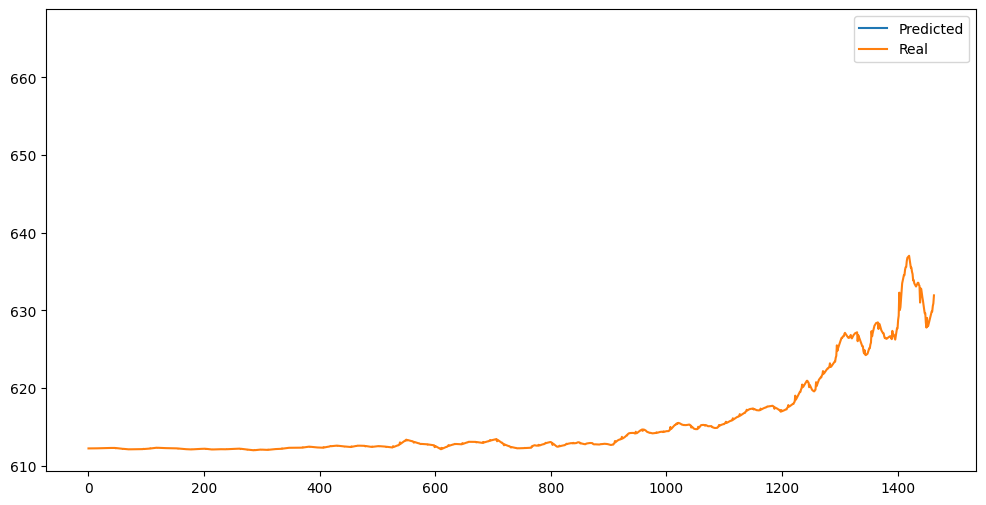

In [18]:
plot_prediction(wg_linear,model)

Pour chacun des modèles, le processus va être le même. Dans TensorFlow, lorsqu’un modèle tf.keras.Sequential fait un fit, il renvoie un objet History dans lequel on a accès à toutes les métriques pendant chaque epoch. Nous allons donc affecter chaque objet History à une variable afin de pouvoir les évaluer plus en détail par la suite.

#### La régression linéaire multiple

Ici, notre premier modèle est la régression linéaire multiple. Étant un modèle moins lourd que le réseau neuronal dense et les LSTM, nous avons choisi de l’entraîner avec un plus grand nombre d’epochs.

In [19]:

model = build_linear_model(wg_linear.training_input.shape[1:])
history_linear = model.fit(wg_linear.training_input,wg_linear.training_label,epochs= 80,
                           validation_data=(wg_linear.val_input, wg_linear.val_label),batch_size=BATCH_SIZE,callbacks=[callback])

Epoch 1/80
122/122 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 1.1968 - mae: 0.9917 - val_loss: 3.4964 - val_mae: 1.7631
Epoch 2/80
122/122 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.6062 - mae: 0.6894 - val_loss: 2.5438 - val_mae: 1.5005
Epoch 3/80
122/122 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.2854 - mae: 0.4524 - val_loss: 1.9020 - val_mae: 1.2928
Epoch 4/80
122/122 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.1318 - mae: 0.2944 - val_loss: 1.4856 - val_mae: 1.1368
Epoch 5/80
122/122 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0669 - mae: 0.2127 - val_loss: 1.2214 - val_mae: 1.0248
Epoch 6/80
122/122 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0414 - mae: 0.1719 - val_loss: 1.0532 - val_mae: 0.9457
Epoch 7/80
122/122 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0305 - mae: 0.1482 - val_loss: 0.9415 - val_mae: 0.8888
Epoch 8/80
122/122 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0244 - mae: 0.1307 - val_loss: 0.8612 - val_mae: 0.8451
Epoch 9/80
122/122 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - lo

Le plot des données d’entraînement montre un entraînement satisfaisant, on voit que le modèle reste très précis sur les données d’entraînement. Néanmoins, la véritable puissance d’un modèle réside dans sa capacité à prédire des données inconnues.

46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


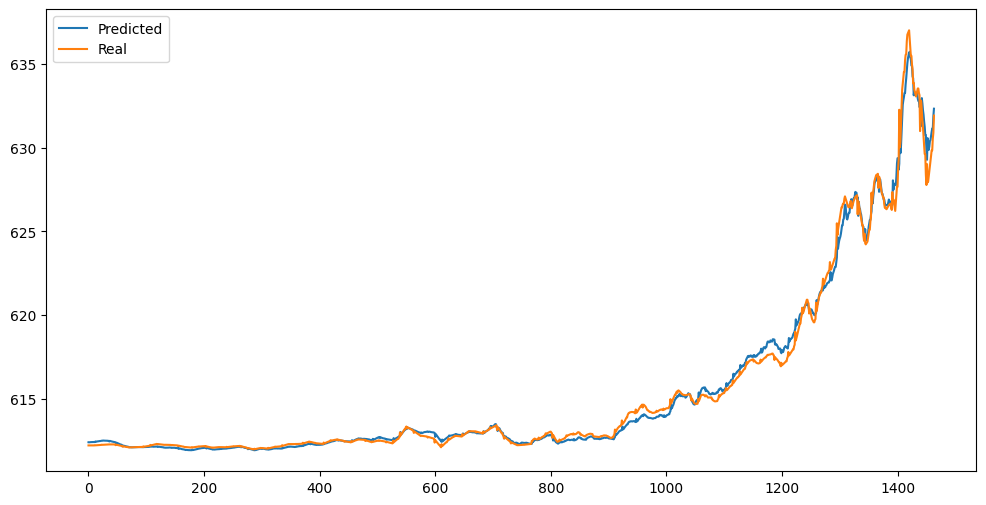

In [20]:
plot_prediction(wg_linear,model)

Pour les données de prédiction, on voit que le modèle a tendance à prédire des valeurs légèrement inférieures aux valeurs réelles. Néanmoins, il reste très fiable, car la courbe prédite suit bien la courbe réelle avec un écart moyenne.

6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 


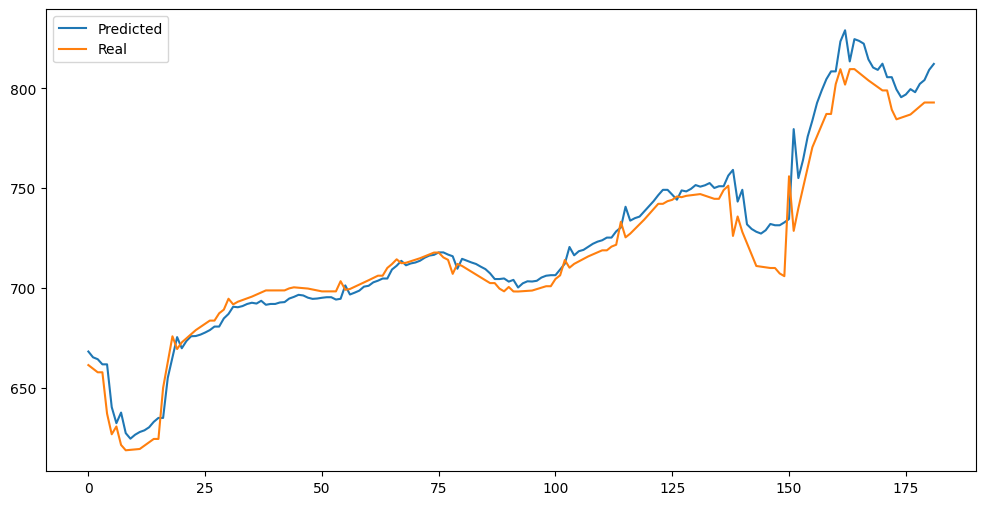

In [21]:
plot_prediction_test(wg_linear,model)

Dans l’ensemble, le modèle a tendance à prédire des valeurs légèrement inférieures aux valeurs réelles, mais il reste très fiable quant à la forme de la courbe et ne montre pas de signes importants de surapprentissage.

58/58 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


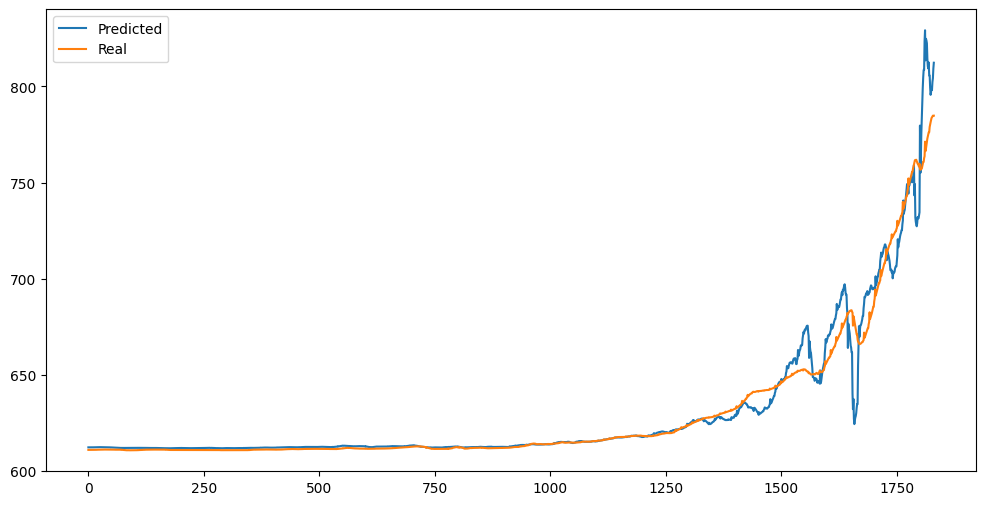

In [22]:
plot_prediction_test_general(wg_linear,model,2)

### La régression linéaire simple 

Notre deuxième modèle est la régression linéaire simple. Avec la même logique que pour la régression multiple, le nombre d’epochs est supérieur, car il s’agit d’un modèle plus simple, mais inférieur à celui de la régression multiple afin d’éviter le surapprentissage.

In [23]:


model = build_linear_model(wg_linear_uni_variable.training_input.reshape(-1, 1).shape[1:])
history_linear_uni = model.fit(wg_linear_uni_variable.training_input.reshape(-1, 1),wg_linear_uni_variable.training_label,
                               epochs= 80 ,validation_data=(wg_linear_uni_variable.val_input, wg_linear_uni_variable.val_label), batch_size= BATCH_SIZE,callbacks=[callback])

Epoch 1/80
122/122 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0436 - mae: 0.1944 - val_loss: 0.3383 - val_mae: 0.5168
Epoch 2/80
122/122 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0113 - mae: 0.0986 - val_loss: 0.3289 - val_mae: 0.5225
Epoch 3/80
122/122 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0052 - mae: 0.0581 - val_loss: 0.3109 - val_mae: 0.5122
Epoch 4/80
122/122 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0043 - mae: 0.0462 - val_loss: 0.2871 - val_mae: 0.4930
Epoch 5/80
122/122 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0039 - mae: 0.0424 - val_loss: 0.2608 - val_mae: 0.4697
Epoch 6/80
122/122 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0035 - mae: 0.0400 - val_loss: 0.2338 - val_mae: 0.4443
Epoch 7/80
122/122 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0031 - mae: 0.0377 - val_loss: 0.2068 - val_mae: 0.4175
Epoch 8/80
122/122 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0028 - mae: 0.0353 - val_loss: 0.1807 - val_mae: 0.3897
Epoch 9/80
122/122 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - lo

Le résultat sur les données d’entraînement reste impeccable, le modèle est pratiquement parfait sur les données connues.

46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 


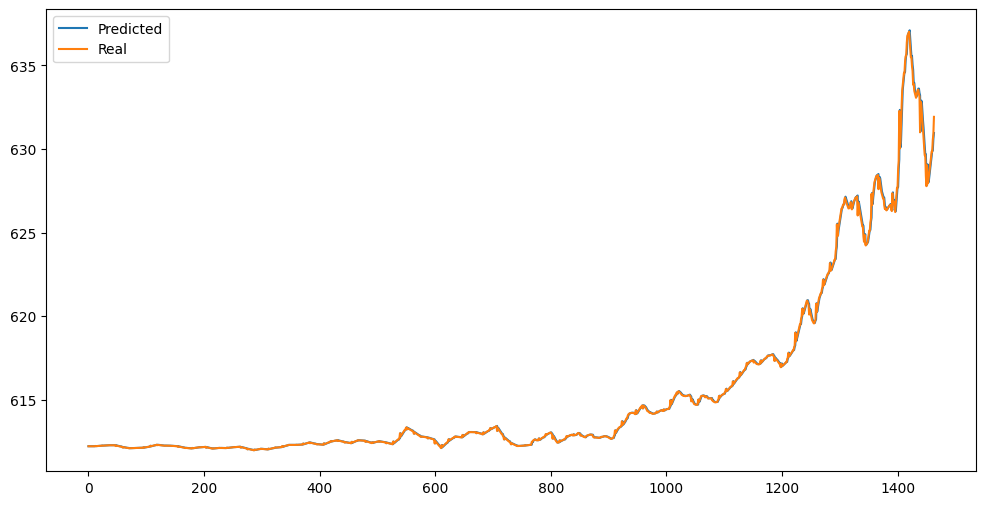

In [24]:
plot_prediction(wg_linear_uni_variable,model)

À la différence de la régression multiple, ici on ne voit pas un patron clair sur la manière dont les variables sont prédites, mais le modèle reste très précis sur les variables inconnues.

6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 


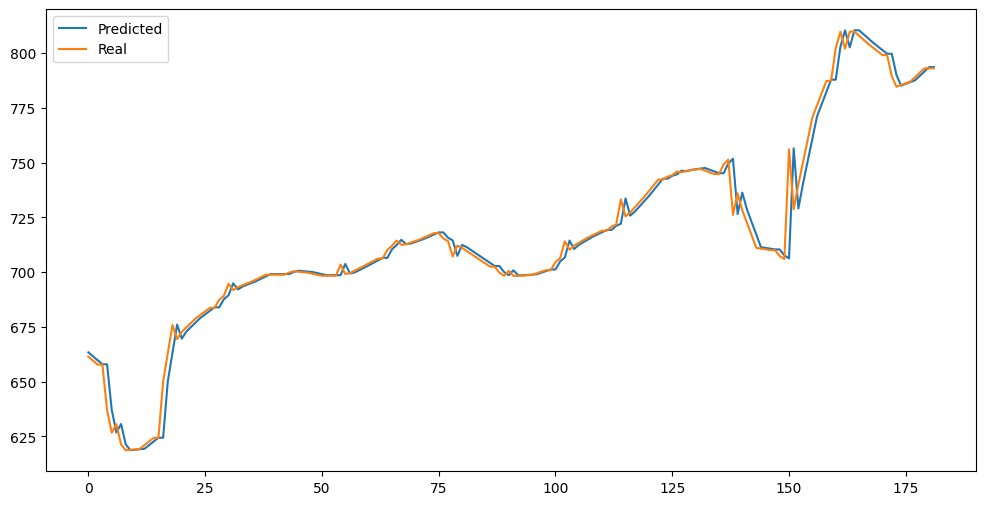

In [25]:
plot_prediction_test(wg_linear_uni_variable,model)

La performance de la régression linéaire simple reste largement supérieure à celle de la régression linéaire multiple. Pour l’ensemble du dataset, la prédiction reste très fiable.

58/58 ━━━━━━━━━━━━━━━━━━━━ 0s 981us/step


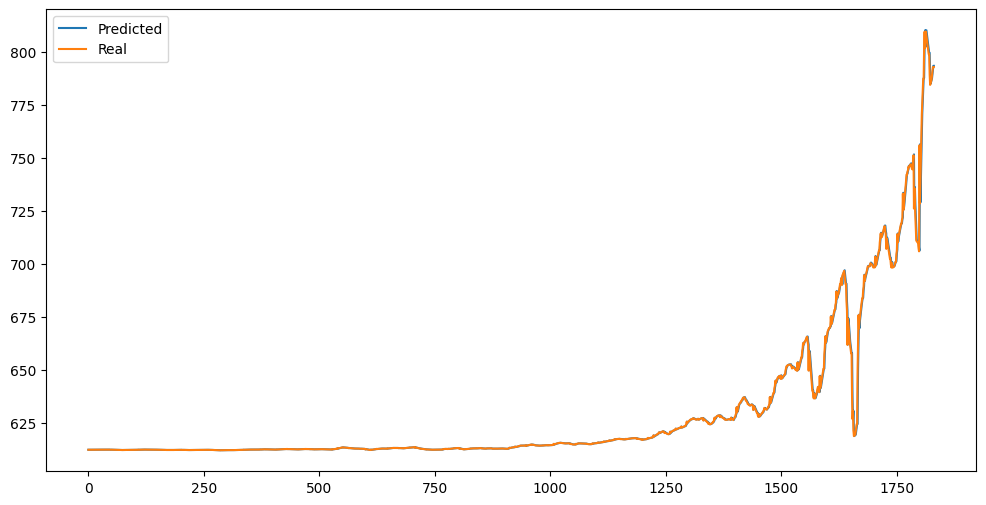

In [26]:
plot_prediction_test_general(wg_linear_uni_variable,model)

### Reseaux neuronal 

Pour l’entraînement du réseau de neurones, afin d’éviter le overfitting, on a décidé d’utiliser un nombre d’epochs moins élevé pour éviter le surapprentissage.

In [27]:
model = build_dense_model(wg_linear.training_input.shape[1:])
history_dense = model.fit(wg_linear.training_input,wg_linear.training_label,epochs= EPOCHS,
                          validation_data=(wg_linear.val_input, wg_linear.val_label),batch_size=BATCH_SIZE,callbacks=[callback])

Epoch 1/40
122/122 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.3216 - mae: 0.4380 - val_loss: 0.1753 - val_mae: 0.3237
Epoch 2/40
122/122 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0874 - mae: 0.2236 - val_loss: 0.1412 - val_mae: 0.2930
Epoch 3/40
122/122 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0562 - mae: 0.1781 - val_loss: 0.1931 - val_mae: 0.3623
Epoch 4/40
122/122 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0377 - mae: 0.1444 - val_loss: 0.1868 - val_mae: 0.3596
Epoch 5/40
122/122 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0268 - mae: 0.1233 - val_loss: 0.1506 - val_mae: 0.3205
Epoch 6/40
122/122 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0192 - mae: 0.1055 - val_loss: 0.1062 - val_mae: 0.2621
Epoch 7/40
122/122 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0145 - mae: 0.0924 - val_loss: 0.1066 - val_mae: 0.2663
Epoch 8/40
122/122 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0124 - mae: 0.0846 - val_loss: 0.0901 - val_mae: 0.2449
Epoch 9/40
122/122 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - lo

Pour les données d’entraînement, on voit que le modèle est moins bien adapté que la régression linéaire. Néanmoins, l’importance d’un modèle, comme dit précédemment, est sa capacité à généraliser. Étant donné que ce graphique est surtout utile pour détecter de l’underfitting, il ne reflète pas la puissance générale du modèle.

46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


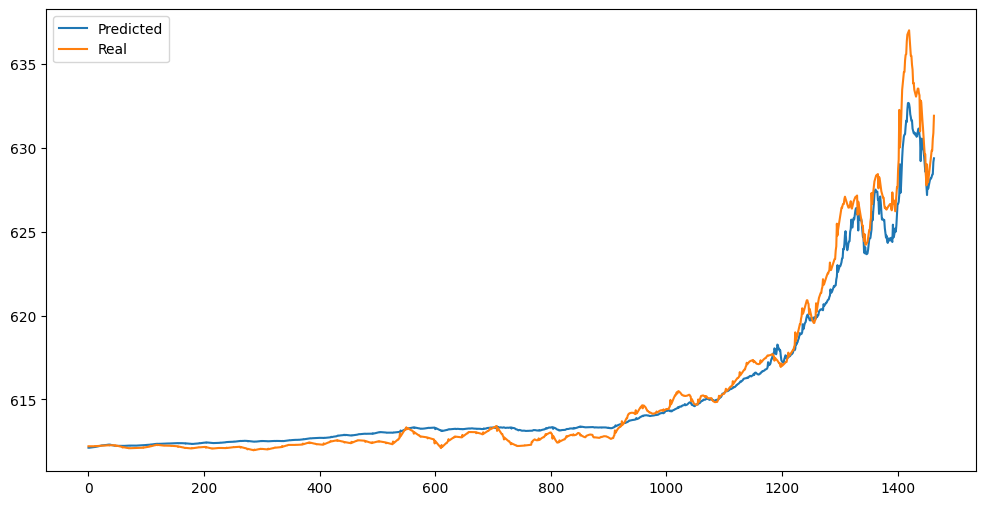

In [28]:
plot_prediction(wg_linear,model)

Pour la validation, on voit une bonne performance du réseau neuronal, mais moins bonne que la régression simple et multiple. Il reste quand même des résultats très positifs, avec la courbe prédite suivant bien la courbe réelle, mais avec des problèmes lors des chutes, le modèle exagère les baisse de performance.

6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 


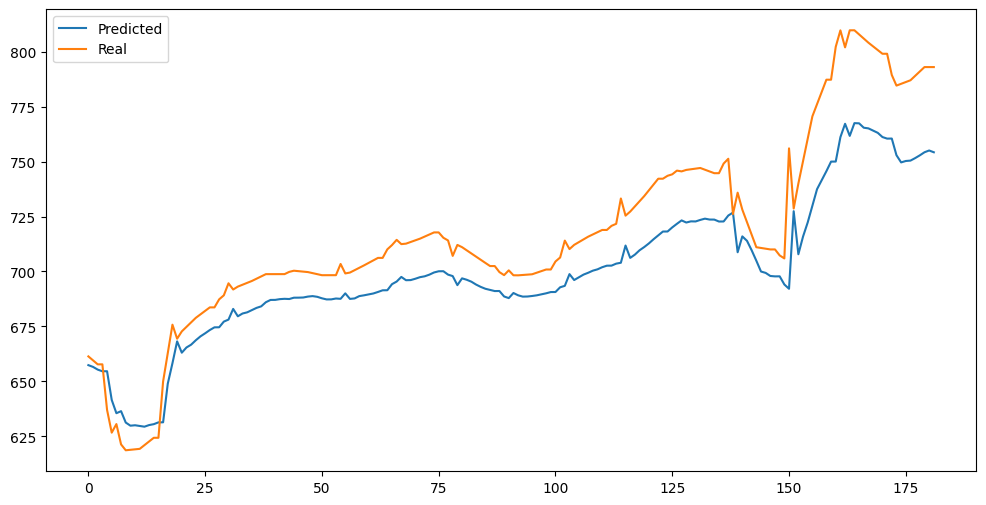

In [29]:
plot_prediction_test(wg_linear,model)

Le résultat du réseau neuronal reste bon. Il a généralisé les données d’une bonne manière, mais moins bon que la régression linéaire simple et multiple.

58/58 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 


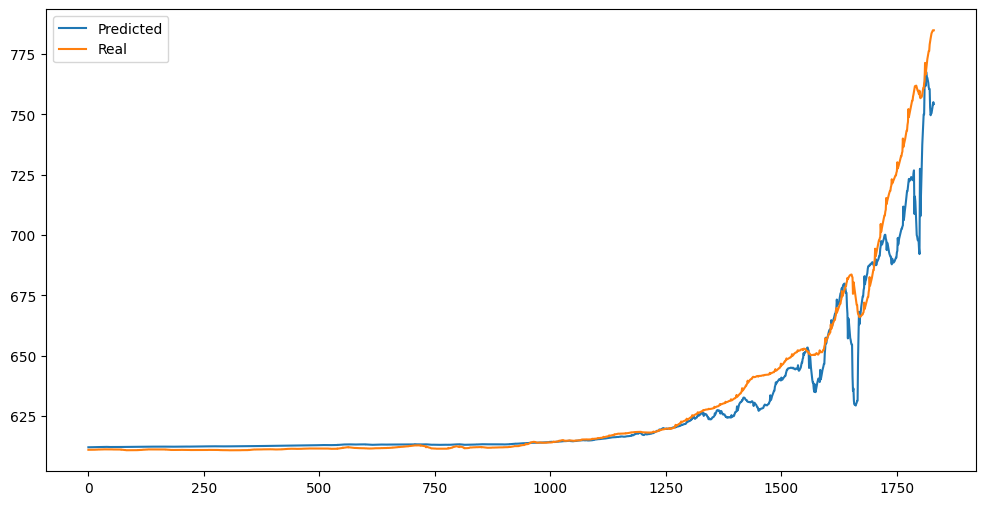

In [30]:
plot_prediction_test_general(wg_linear,model,2)

La seule remarque technique à faire pour la LSTM est que le batch size est propre à la classe de données de l’objet WindowGenerator.

In [31]:
model = build_lstm_model(wg_lstm.training_input.shape[1:])
history_lstm = model.fit(wg_lstm.training_tf,validation_data=wg_lstm.val_tf,epochs= EPOCHS,callbacks=[callback])

Epoch 1/40
46/46 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - loss: 0.0605 - mae: 0.2045 - val_loss: 0.6247 - val_mae: 0.6454
Epoch 2/40
46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0281 - mae: 0.1305 - val_loss: 0.6962 - val_mae: 0.7053
Epoch 3/40
46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0067 - mae: 0.0661 - val_loss: 0.6844 - val_mae: 0.6992
Epoch 4/40
46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0055 - mae: 0.0598 - val_loss: 0.6478 - val_mae: 0.6738
Epoch 5/40
46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0045 - mae: 0.0530 - val_loss: 0.6329 - val_mae: 0.6656
Epoch 6/40
46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0051 - mae: 0.0570 - val_loss: 0.6090 - val_mae: 0.6498
Epoch 7/40
46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0040 - mae: 0.0496 - val_loss: 0.5886 - val_mae: 0.6352
Epoch 8/40
46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0040 - mae: 0.0503 - val_loss: 0.5658 - val_mae: 0.6198
Epoch 9/40
46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0039 - mae: 

Pour les données d’entraînement, on voit que la LSTM, parmi tous les modèles que nous avons vus jusqu’à présent, est celle dont la courbe prédite est la moins fidèle à la courbe réelle. Mais elle continue à suivre la courbe réelle et la tendance, que le modèle semble bien capter. En revanche, on voit qu’elle a des problèmes avec le bruit.

46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step


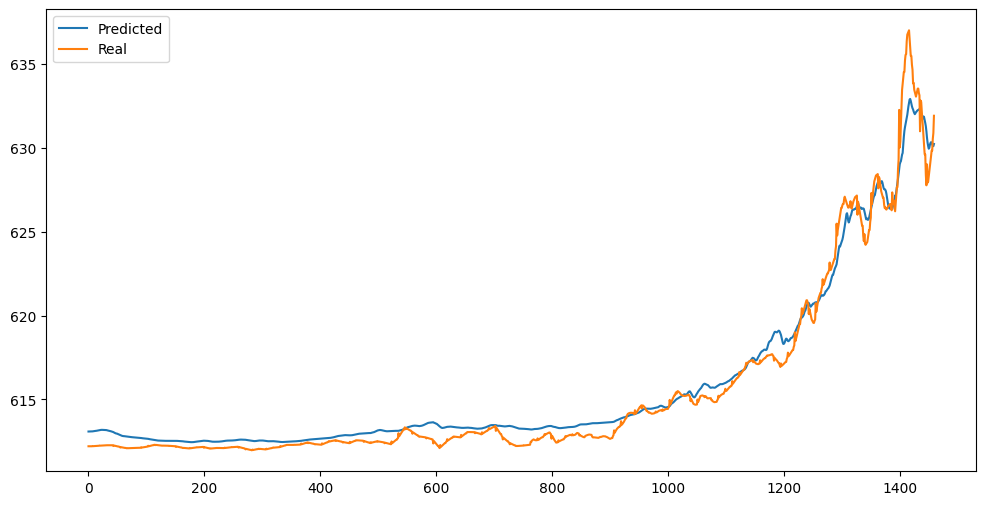

In [32]:
plot_prediction(wg_lstm,model)

Pour la prédiction générale, c’est très mauvais. on voit clairement du surapprentissage, le modèle n’a pas été capable de généraliser. On a l’hypothèse que cela est dû à la longueur des données, le modèle restant trop fixé sur les données passées.

58/58 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


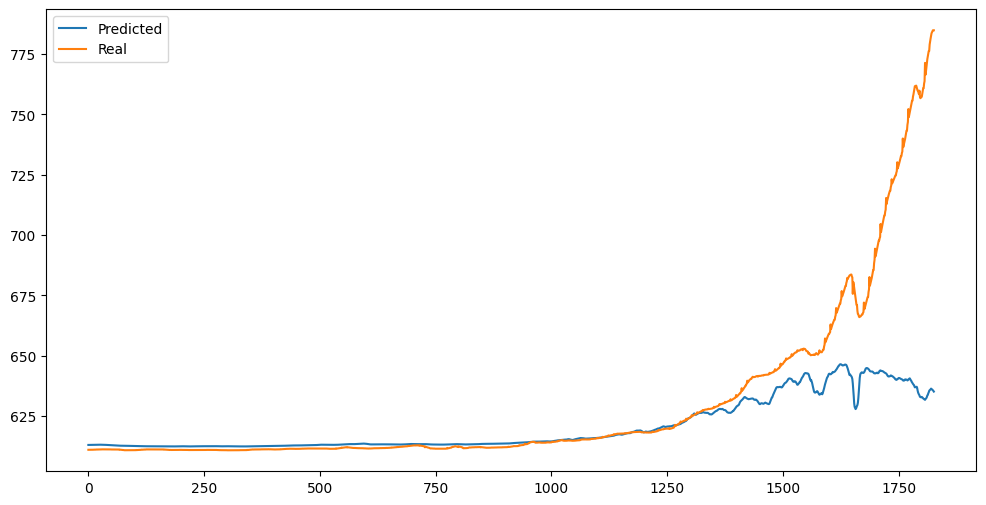

In [33]:
plot_prediction_test_general(wg_lstm,model,2)

Dans l’entraînement, tous les modèles ont eu un MSE plus bas que la baseline, ce qui est un bon indicatif de l’appropriation des données d’entraînement.

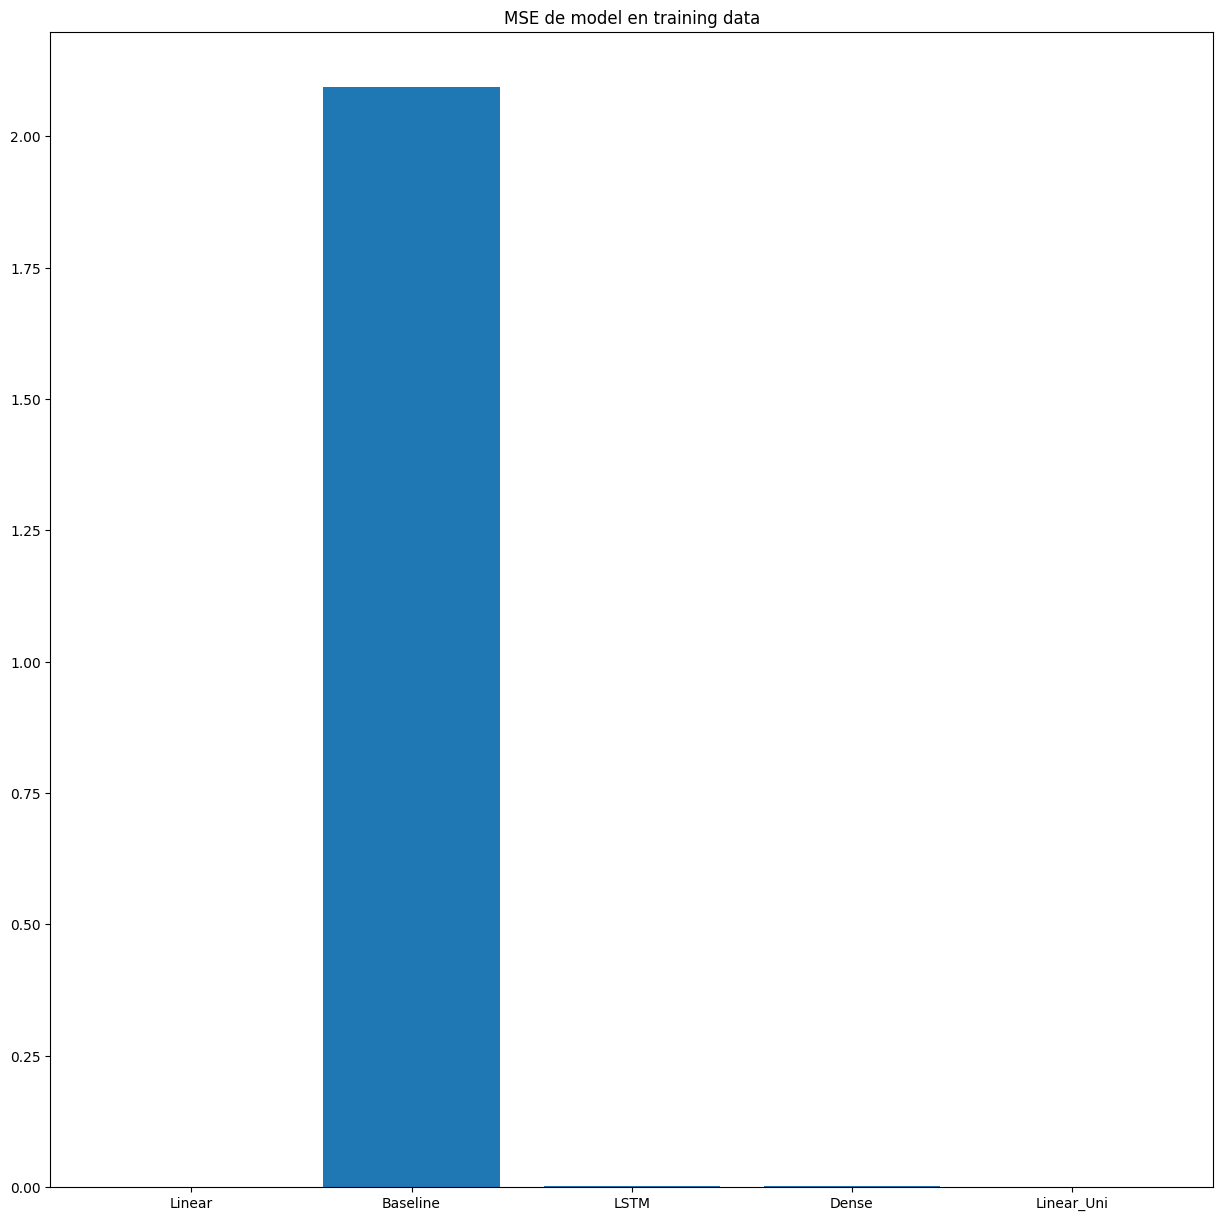

In [34]:
models = {
    "Linear": history_linear,
    "Baseline": history_baseline,
    "LSTM": history_lstm,
    "Dense": history_dense,
    "Linear_Uni": history_linear_uni
}



models_val = {
    "Linear": history_linear,
    "LSTM": history_lstm,
    "Dense": history_dense,
    "Linear_Uni": history_linear_uni
}

plot_bar_metrics("loss", models,"MSE de model en training data")

Par contre, pour les données de validation, comme on l’a vu dans les graphiques précédents, la LSTM a fait du surapprentissage, contrairement aux autres modèles. On voit bien que la régression linéaire simple reste la meilleure de tous les modèles,puis de la régression linéaire multiple.

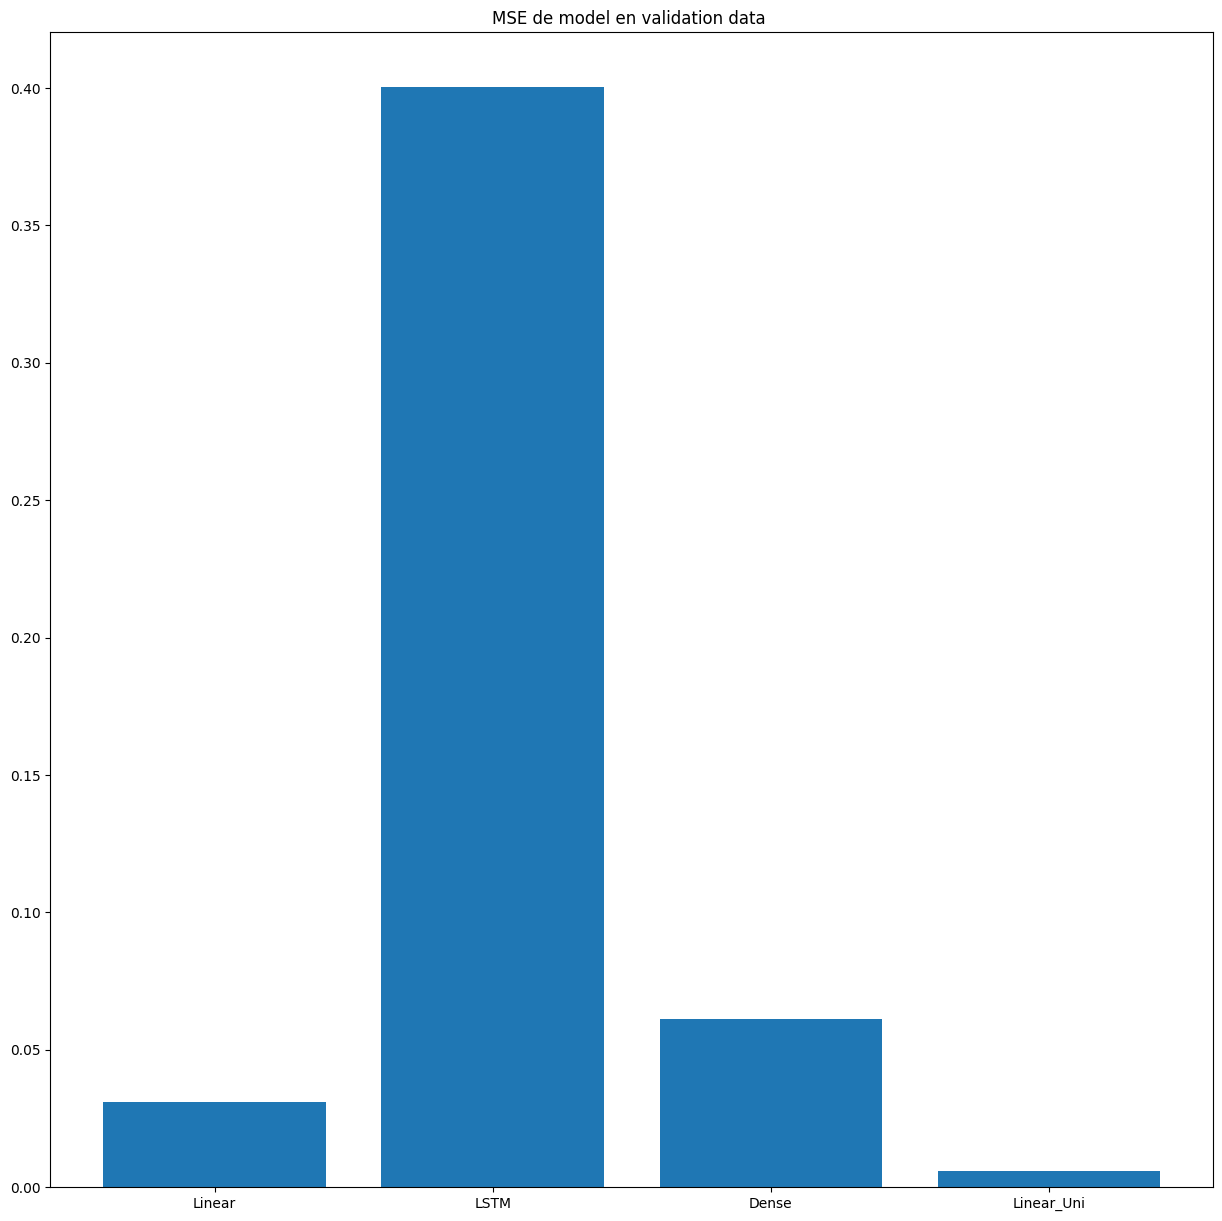

In [35]:
plot_bar_metrics("val_loss", models_val,"MSE de model en validation data ")

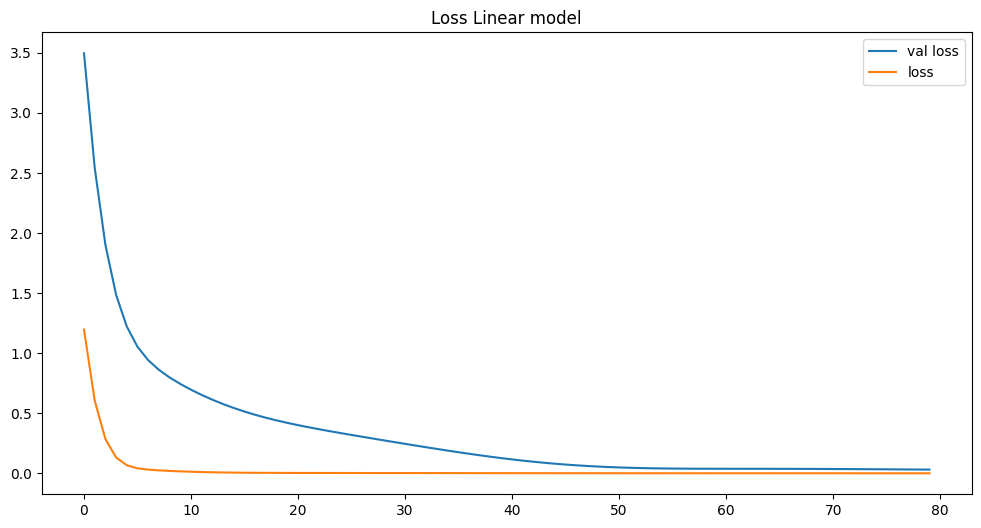

In [36]:
plot_training_validation(models_val["Linear"].history,"loss","Loss Linear model")

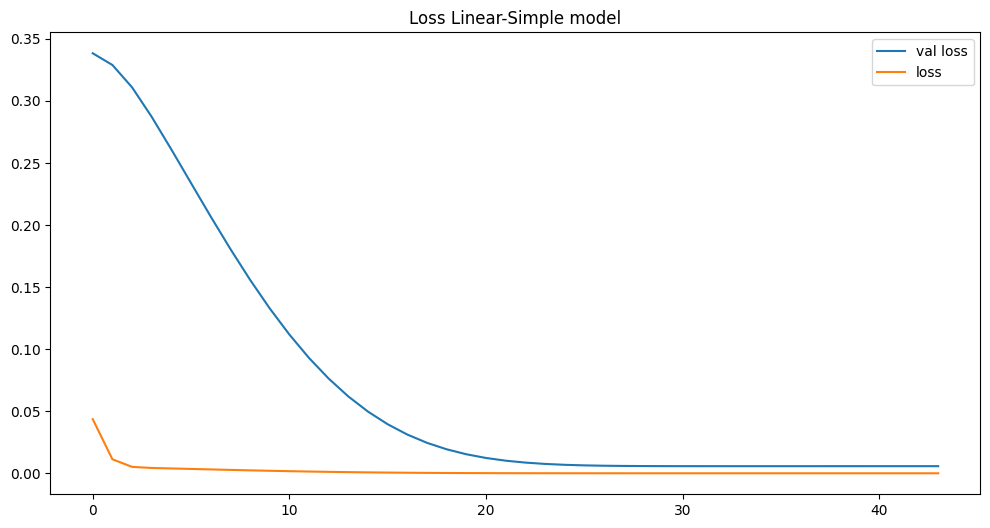

In [37]:
plot_training_validation(models_val["Linear_Uni"].history,"loss","Loss Linear-Simple model")

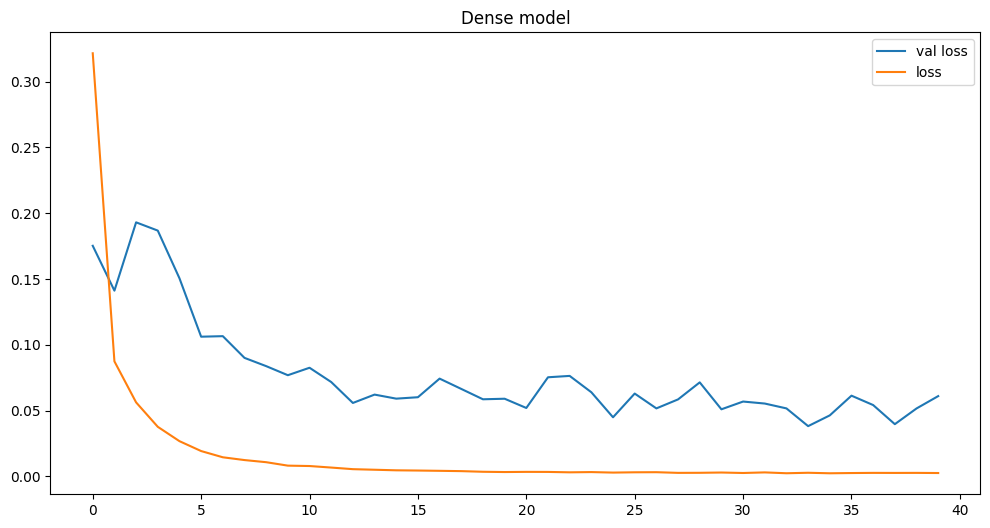

In [38]:
plot_training_validation(models_val["Dense"].history,"loss","Dense model")

Grâce à ce graphique, on voit comment la LSTM a fait du surapprentissage, ce qui peut être dû à plusieurs facteurs. Nous avons utilisé le dropout comme méthode de régularisation, mais la L1 regularization aurait également pu nous aider. Un autre motif est peut-être la longueur des données, les LSTM ont souvent besoin de plus de données que d’autres modèles pour être capables de généraliser.

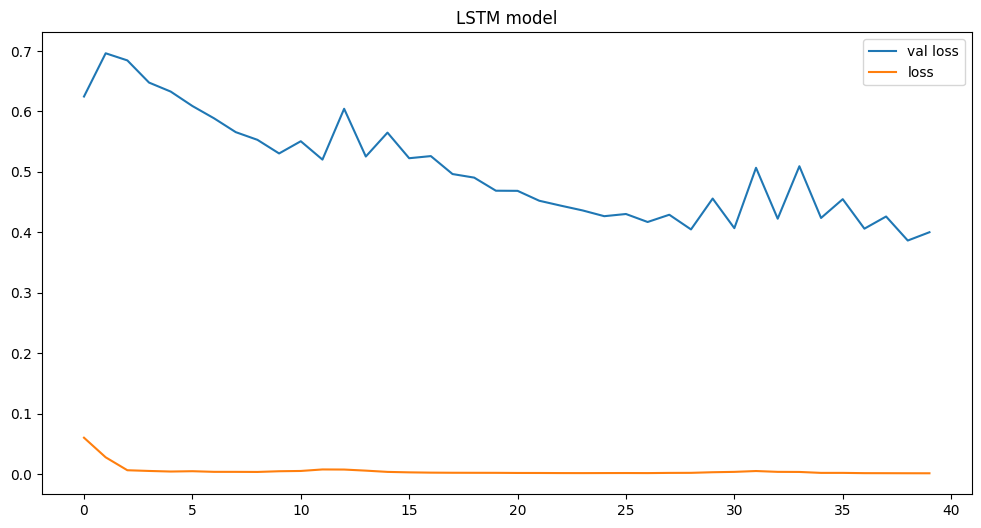

In [39]:
plot_training_validation(models_val["LSTM"].history,"loss","LSTM model")

## 4. Régression linéaire multiple avec l’ensemble du dataset

Dans cette partie, nous allons nous concentrer sur la manière dont l’ajout de variables au modèle de régression linéaire multiple peut aider ou non à la prédiction. Le problème dans cette partie est que la longueur des données n’est pas la même pour chaque variable. nous allons donc expliciter le shape des données pour chaque cas.


### 4.1 Inflation dataset 

L’inflation reste un indicateur macroéconomique important, qui reflète l’augmentation des prix. Dans cette partie, nous allons évaluer comment l’ajout de l’inflation comme variable dans notre régression linéaire multiple peut affecter la performance de notre modèle.

In [40]:

df = import_joinTable(bdd,import_inflation_table(bdd))
df_model = standar_df(df.copy())

MEAN_EARNINGS = df["earnings"].mean()
STD_EARNINGS = df["earnings"].std()

df_model

,sp500,dividend,earnings,longInterestRate,realPrice,realDividend,realEarnings,CPI
observation_date,,,,,,,,
1913-01-01,-0.588370,-0.653842,-0.635881,-0.168664,-0.694595,-0.660434,-0.795883,-0.900723
1913-02-01,-0.588103,-0.653842,-0.635237,-0.134584,-0.684523,-0.648504,-0.771681,-0.900723
1913-03-01,-0.588342,-0.653842,-0.635421,-0.145944,-0.690804,-0.648504,-0.776899,-0.900723
1913-04-01,-0.588356,-0.653842,-0.635604,-0.153517,-0.691171,-0.648504,-0.782116,-0.900723
1913-05-01,-0.588693,-0.653842,-0.635791,-0.164877,-0.696789,-0.635779,-0.781246,-0.900723
...,...,...,...,...,...,...,...,...
2020-09-01,4.127306,3.798103,2.452465,-1.554579,3.666381,3.664399,1.953358,2.262810
2020-10-01,4.127306,3.798103,2.452465,-1.554579,3.666381,3.664399,1.953358,2.262810
2020-11-01,4.385052,3.769120,2.366142,-1.482633,3.922611,3.629406,1.861190,2.262810


#### Shape:

In [41]:
df_model.shape

(1297, 8)

#### WindowGenerator:

In [42]:
target_index = df_model.columns.get_loc(target_col)

wg_linear = WindowGenerator(
    df=df_model,
    input_width=1,
    shift=1,
    p_val_df=P_VAL,
    p_test_df=P_TEST,
    label_width=1,
    label_encoder= target_index
)

In [43]:

model = build_linear_model(wg_linear.training_input.shape[1:])
history_linear_inflation = model.fit(wg_linear.training_input,wg_linear.training_label,epochs= 80,
                           validation_data=(wg_linear.val_input, wg_linear.val_label),batch_size=BATCH_SIZE,callbacks=[callback])

models_val["Linear_inflation"] = history_linear_inflation

Epoch 1/80
87/87 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.6700 - mae: 0.6664 - val_loss: 1.4898 - val_mae: 1.1508
Epoch 2/80
87/87 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.3464 - mae: 0.4296 - val_loss: 0.8778 - val_mae: 0.8498
Epoch 3/80
87/87 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.2177 - mae: 0.3276 - val_loss: 0.6477 - val_mae: 0.6987
Epoch 4/80
87/87 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.1579 - mae: 0.2839 - val_loss: 0.5681 - val_mae: 0.6371
Epoch 5/80
87/87 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.1207 - mae: 0.2537 - val_loss: 0.5355 - val_mae: 0.6106
Epoch 6/80
87/87 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0944 - mae: 0.2288 - val_loss: 0.5118 - val_mae: 0.5908
Epoch 7/80
87/87 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0752 - mae: 0.2070 - val_loss: 0.4858 - val_mae: 0.5680
Epoch 8/80
87/87 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0608 - mae: 0.1877 - val_loss: 0.4559 - val_mae: 0.5402
Epoch 9/80
87/87 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0496 - mae: 

Le modèle de régression linéaire avec l’inflation donne de très bons résultats sur les données connues, on ne constate pas d’underfitting.

33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 


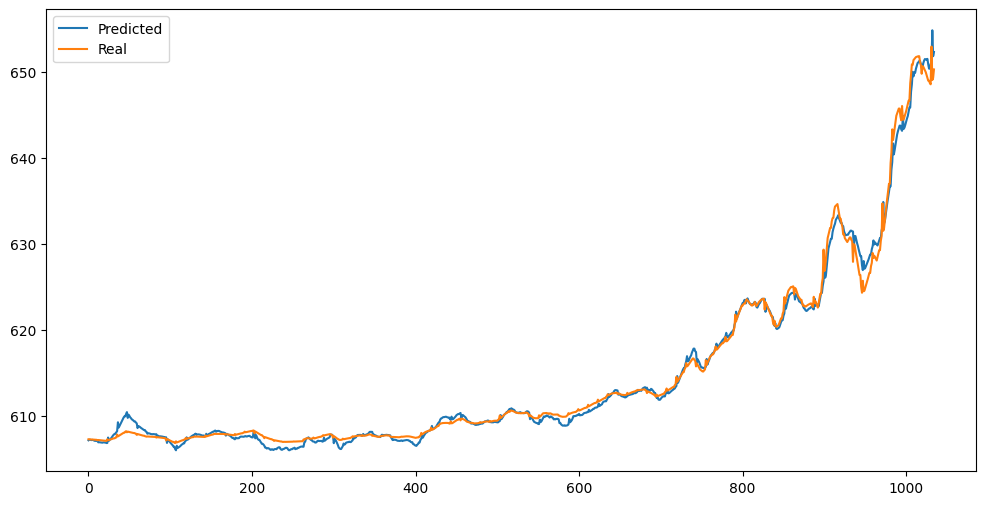

In [44]:
plot_prediction(wg_linear,model)


Sur l’ensemble des données, il donne de résultats similaire que le modèle de régression linéaire utilisant uniquement les données du S&P 500.

41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 


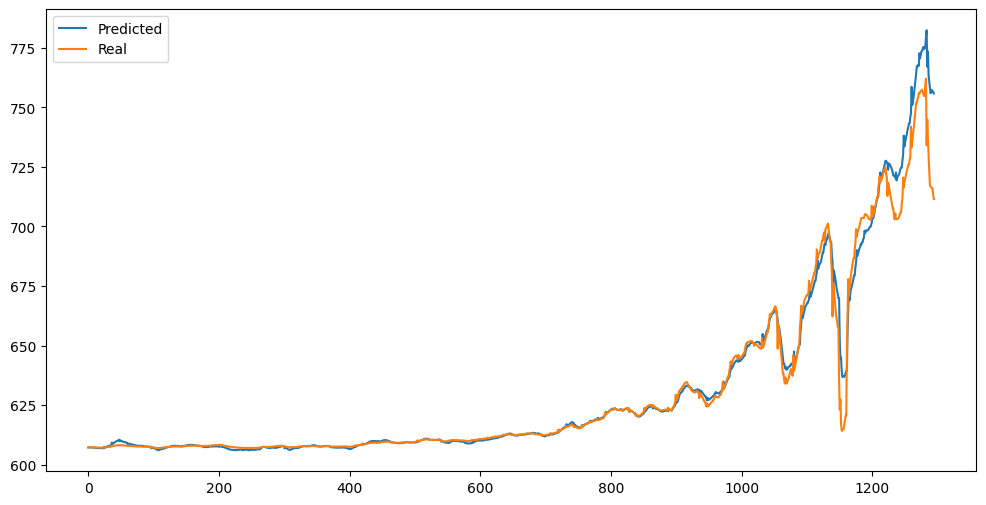

In [45]:
plot_prediction_test_general(wg_linear,model,target_index)

De même, pour les données de test, il reste beaucoup similaire que la première régression linéaire multiple.

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 


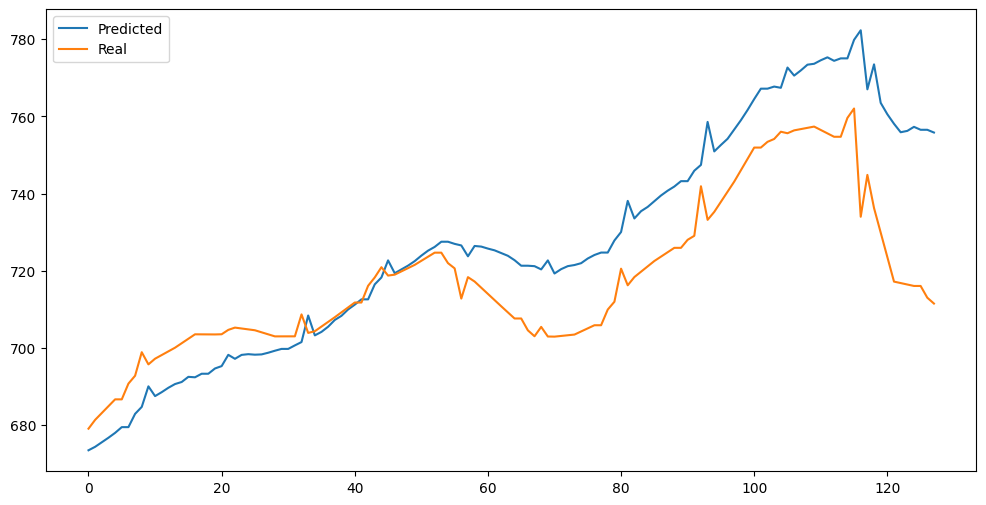

In [46]:
plot_prediction_test(wg_linear,model)

Nous voyons que la performance reste similaire dans les deux régressions linéaires multiples. Néanmoins, d’un point de vue explicatif, le fait qu’elles restent similaires avec l’ajout de la variable peut indiquer que, dans le futur, ce modèle pourrait être une option intéressante.

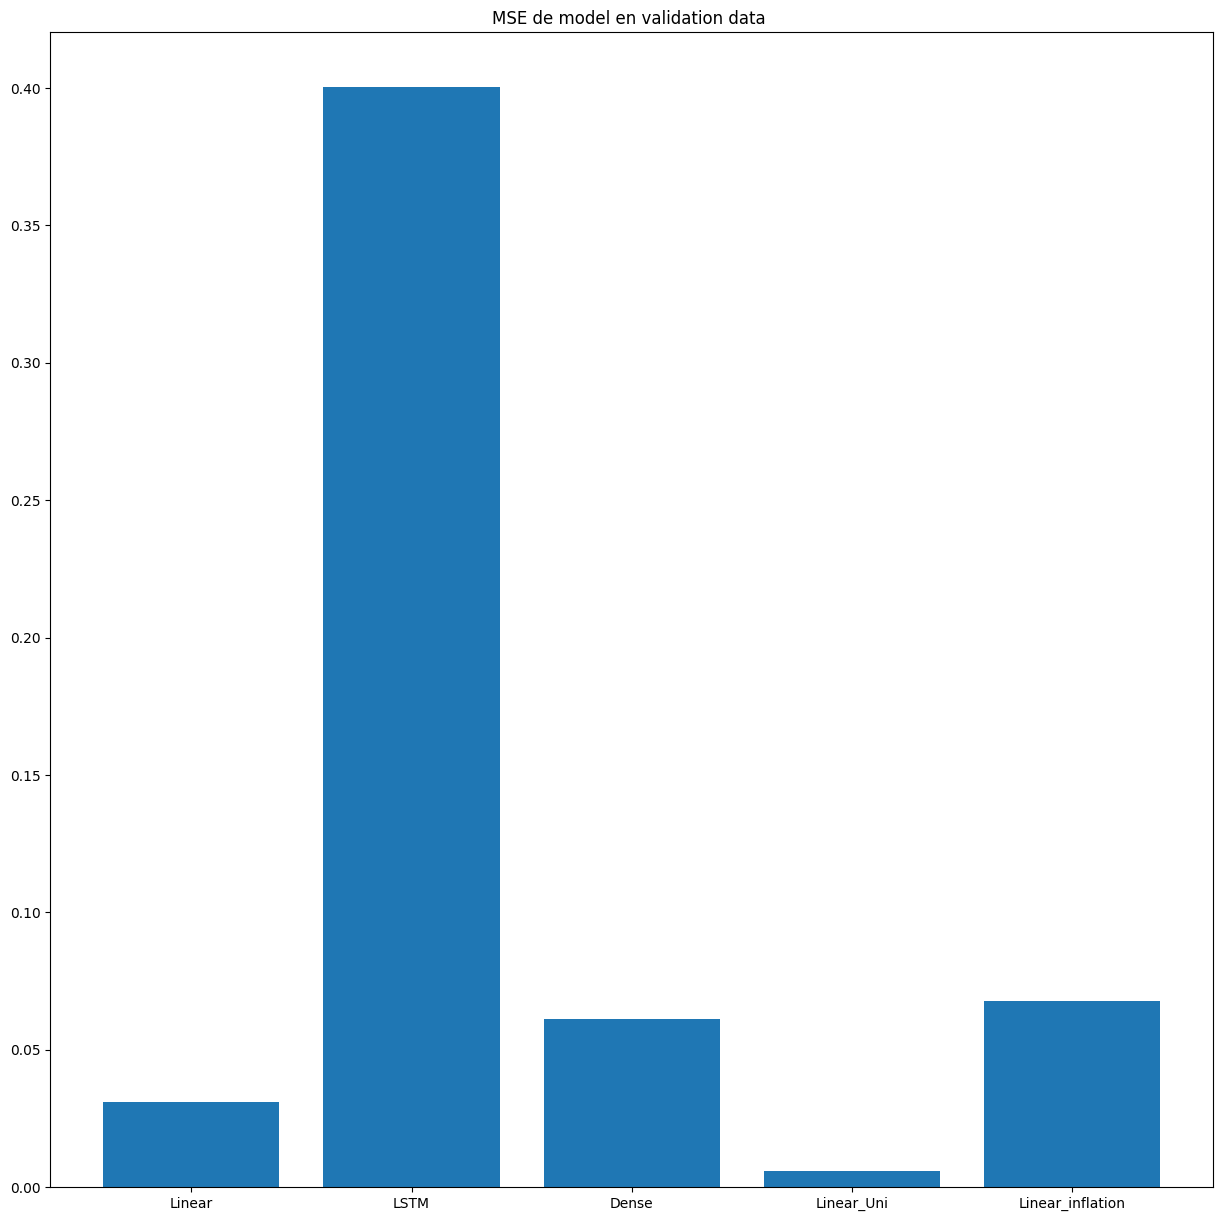

In [47]:
plot_bar_metrics("val_loss", models_val,"MSE de model en validation data ")

### 4.2 Inflation et BigMac Index table.

Comme vu dans le chapitre précédent, le modèle avec l’inflation reste le deuxième modèle le plus puissant. Étant donné cela, nous allons ajouter comme deuxième dataset le prix moyen mondial du Big Mac.

In [48]:

df = import_joinTable(bdd,import_inflation_table(bdd),import_bigmacindex_table(bdd))

df_model = standar_df(df.copy())


MEAN_EARNINGS = df["earnings"].mean()
STD_EARNINGS = df["earnings"].std()

df_model

,sp500,dividend,earnings,longInterestRate,realPrice,realDividend,realEarnings,CPI,dollar_price
observation_date,,,,,,,,,
2000-05-01,-0.358853,-1.088813,-0.750258,2.494298,0.359399,-0.938424,-0.307621,-1.763337,-1.526780
2000-06-01,-0.296529,-1.090278,-0.740169,2.229101,0.450133,-0.952979,-0.305075,-1.763337,-1.526780
2000-07-01,-0.280705,-1.099071,-0.721654,2.190101,0.469332,-0.972628,-0.281308,-1.763337,-1.526780
2000-08-01,-0.262845,-1.107131,-0.703135,2.018503,0.500640,-0.987910,-0.251600,-1.763337,-1.526780
2000-09-01,-0.287800,-1.115924,-0.684620,1.995103,0.437797,-1.013381,-0.235755,-1.763337,-1.526780
...,...,...,...,...,...,...,...,...,...
2020-09-01,2.432021,1.998161,0.704728,-1.998455,2.381882,1.926668,0.355020,1.623827,0.689675
2020-10-01,2.432021,1.998161,0.704728,-1.998455,2.381882,1.926668,0.355020,1.623827,0.689675
2020-11-01,2.695005,1.970317,0.619635,-1.850256,2.689022,1.894647,0.265045,1.623827,0.689675


### Shape:

In [49]:
df_model.shape

(249, 9)

### WindowGenerator:

In [50]:
target_index = df_model.columns.get_loc(target_col)

wg_linear = WindowGenerator(
    df=df_model,
    input_width=1,
    shift=1,
    p_val_df=P_VAL,
    p_test_df=P_TEST,
    label_width=1,
    label_encoder= target_index
)

In [51]:

model = build_linear_model(wg_linear.training_input.shape[1:])
history_linear_inflation_bigmac = model.fit(wg_linear.training_input,wg_linear.training_label,epochs= 80,
                           validation_data=(wg_linear.val_input, wg_linear.val_label),batch_size=BATCH_SIZE,callbacks=[callback])

models_val["Linear_inflation_bigmac"] = history_linear_inflation_bigmac

Epoch 1/80
17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.9703 - mae: 0.8731 - val_loss: 2.8590 - val_mae: 1.6743
Epoch 2/80
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.7984 - mae: 0.7954 - val_loss: 2.4196 - val_mae: 1.5401
Epoch 3/80
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.6585 - mae: 0.7274 - val_loss: 2.0463 - val_mae: 1.4161
Epoch 4/80
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.5483 - mae: 0.6655 - val_loss: 1.7359 - val_mae: 1.3038
Epoch 5/80
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.4636 - mae: 0.6105 - val_loss: 1.4814 - val_mae: 1.2040
Epoch 6/80
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.3995 - mae: 0.5623 - val_loss: 1.2754 - val_mae: 1.1167
Epoch 7/80
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.3515 - mae: 0.5198 - val_loss: 1.1102 - val_mae: 1.0413
Epoch 8/80
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.3156 - mae: 0.4852 - val_loss: 0.9789 - val_mae: 0.9772
Epoch 9/80
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.2885 - mae:

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 


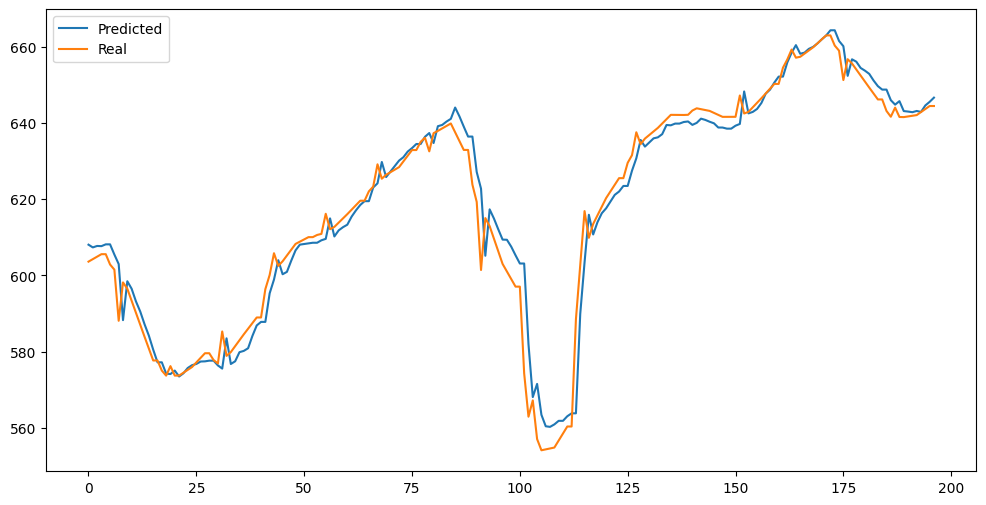

In [52]:
plot_prediction(wg_linear,model)

8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 


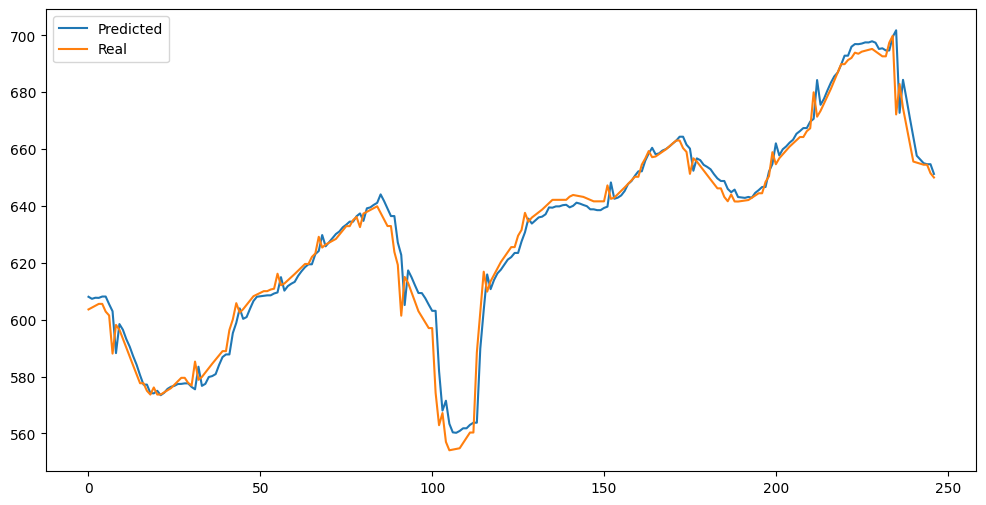

In [53]:
plot_prediction_test_general(wg_linear,model,target_index)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step


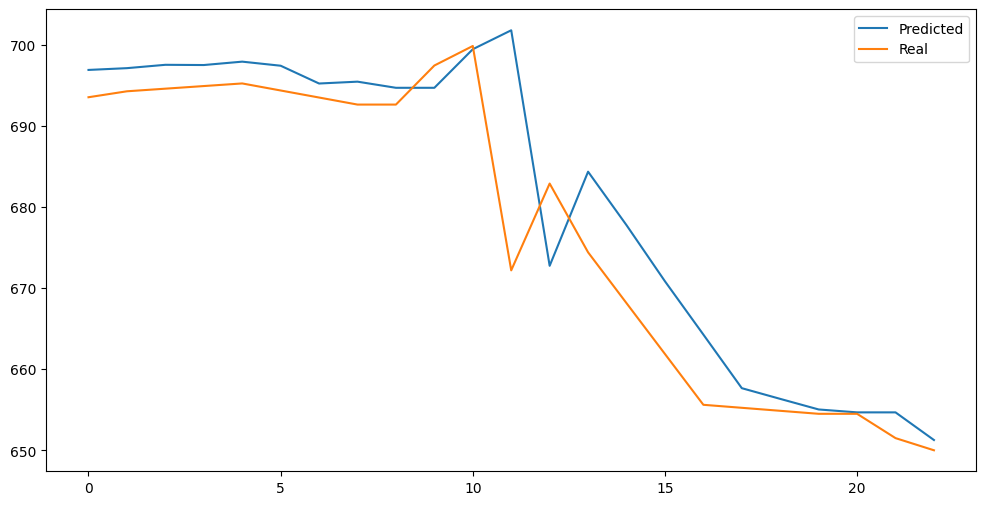

In [54]:
plot_prediction_test(wg_linear,model)

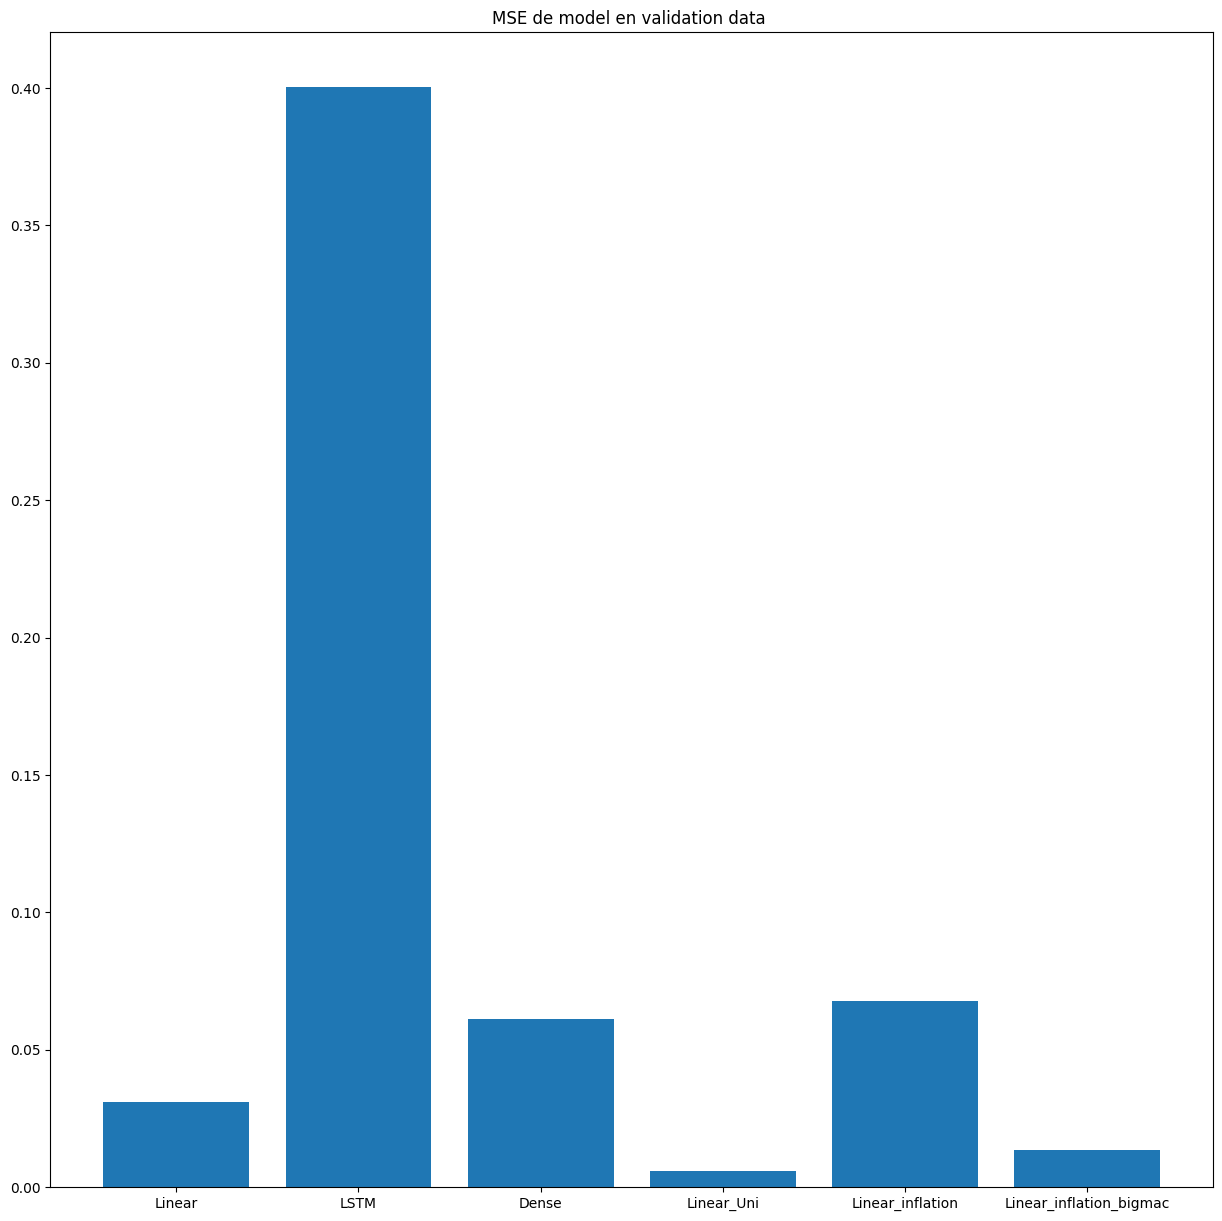

In [55]:
plot_bar_metrics("val_loss", models_val,"MSE de model en validation data ")

Pour le modèle avec le Big Mac et l’inflation, la performance reste meilleure que celle de la LSTM, mais avec environ 1200 individus de moins.
De toute manière, il reste inférieur à la régression linéaire multiple, à la régression linéaire multiple avec l’inflation et à la régression linéaire simple. On peut en conclure que ce dataset n’est pas adapté pour la création du modèle.

### 4.3 Inflation et bitcoin dataset

Le processus reste le même, nous ajoutons le dataset du Bitcoin à notre modèle puis nous comparons sa performance avec celle des autres modèles

In [56]:
df = import_joinTable(bdd,import_inflation_table(bdd),import_bitcoinperformance_table(bdd))
df_model = standar_df(df.copy())

MEAN_EARNINGS = df["earnings"].mean()
STD_EARNINGS = df["earnings"].std()

df_model

,sp500,dividend,earnings,longInterestRate,realPrice,realDividend,realEarnings,CPI,Open,High,Low,Close,Adj_Close,Volume
observation_date,,,,,,,,,,,,,,
2014-10-01,-1.210856,-1.731832,-0.156092,0.766553,-1.246193,-1.962920,0.135046,-1.267697,-0.888950,-0.891341,-0.890881,-0.893297,-0.893297,-0.702869
2014-11-01,-1.105630,-1.635630,-0.297348,0.464032,-1.068874,-1.760528,0.021540,-1.267697,-0.898189,-0.900770,-0.902496,-0.904237,-0.904237,-0.703605
2014-12-01,-1.085749,-1.586766,-0.368005,0.282519,-1.012269,-1.644401,-0.023423,-1.267697,-0.890688,-0.892772,-0.891681,-0.894123,-0.894123,-0.703983
2015-01-01,-1.142687,-1.295109,-0.775766,-0.072943,-1.107597,-1.270308,-0.548730,-1.291730,-0.901638,-0.904496,-0.903868,-0.906411,-0.906411,-0.704270
2015-02-01,-1.028504,-1.447809,-0.486444,-0.065380,-0.935906,-1.443669,-0.166539,-1.291730,-0.921254,-0.920974,-0.923702,-0.922912,-0.922912,-0.702645
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2020-09-01,1.601776,1.377145,-0.605464,-2.031769,1.598086,1.308530,-1.002753,1.498378,1.249725,1.273714,1.291200,1.297356,1.297356,1.399154
2020-10-01,1.601776,1.377145,-0.605464,-2.031769,1.598086,1.308530,-1.002753,1.498378,1.082285,1.063535,1.071682,1.041926,1.041926,2.378436
2020-11-01,1.977814,1.319119,-0.763771,-1.744373,2.039773,1.235536,-1.177124,1.498378,1.647782,1.606557,1.685450,1.631361,1.631361,1.179001


### Shape: 

In [57]:
df_model.shape

(76, 14)

In [58]:
target_index = df_model.columns.get_loc(target_col)

wg_linear = WindowGenerator(
    df=df_model,
    input_width=1,
    shift=1,
    p_val_df=P_VAL,
    p_test_df=P_TEST,
    label_width=1,
    label_encoder= target_index
)

In [59]:

model = build_linear_model(wg_linear.training_input.shape[1:])
history_linear_inflation_bitcoin = model.fit(wg_linear.training_input,wg_linear.training_label,epochs= 80,
                           validation_data=(wg_linear.val_input, wg_linear.val_label),batch_size=BATCH_SIZE,callbacks=[callback])

models_val["Linear_inflation_bitcoin"] = history_linear_inflation_bitcoin

Epoch 1/80
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 40ms/step - loss: 0.7471 - mae: 0.7240 - val_loss: 0.9934 - val_mae: 0.9045
Epoch 2/80
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.6959 - mae: 0.6969 - val_loss: 1.0202 - val_mae: 0.9198
Epoch 3/80
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.6499 - mae: 0.6719 - val_loss: 1.0512 - val_mae: 0.9345
Epoch 4/80
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.6085 - mae: 0.6492 - val_loss: 1.0856 - val_mae: 0.9483
Epoch 5/80
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.5715 - mae: 0.6279 - val_loss: 1.1221 - val_mae: 0.9610
Epoch 6/80
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.5387 - mae: 0.6088 - val_loss: 1.1595 - val_mae: 0.9727
Epoch 7/80
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.5098 - mae: 0.5913 - val_loss: 1.1967 - val_mae: 0.9830
Epoch 8/80
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.4843 - mae: 0.5750 - val_loss: 1.2324 - val_mae: 0.9920
Epoch 9/80
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.4618 - mae: 0.5600 - 

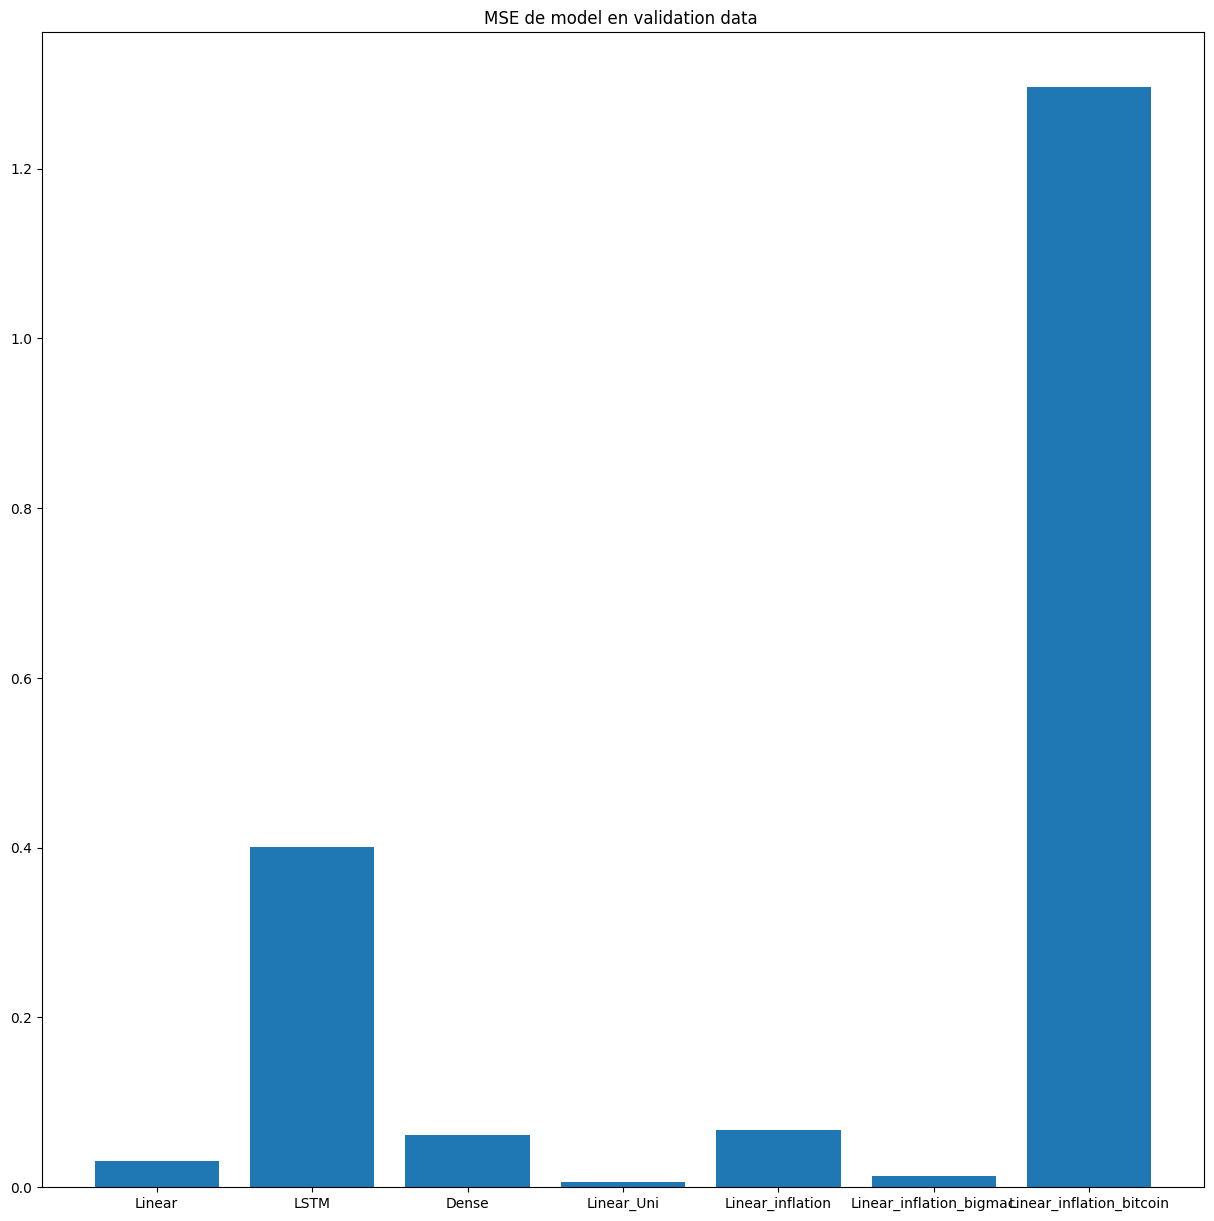

In [60]:
plot_bar_metrics("val_loss", models_val,"MSE de model en validation data ")

Le modèle avec le Bitcoin est très mauvais : nous n’avons que 76 individus, il ne vaut donc pas la peine.

# Conclution 

Comme conclusion de cette partie, le meilleur modèle est la régression linéaire simple. Néanmoins, d’un point de vue d’analyse de plusieurs variables, on pourrait choisir entre la régression linéaire multiple et la régression linéaire multiple avec l’inflation.
Pour moi, il fait beaucoup plus de sens qualitatif de choisir la régression linéaire multiple avec l’inflation, étant donné que c’est un facteur macroéconomique très important et qu’il influence tous les hedge funds.

Il restera à chercher des méthodes pour éviter le surapprentissage dans les modèles de deep learning, étant donné que ce sont les modèles les plus utilisés dans le monde du forecasting. Néanmoins, avec les outils dont nous disposons aujourd’hui et pour garder un modèle facile à expliquer, nous allons choisir comme modèles pour le forecasting la régression linéaire simple et la régression linéaire multiple avec l’inflation, afin qu’ils fassent partie de notre site web.

# Classification Tweets Financiere

La finance reste un monde ou la speculation reste un facteur tres important pour la prise de decision. Une application que les hedge funds et les grandes entreprises de finance quantitative utilisent de plus en plus pour detecter si il commence a y avoir de mauvaise speculation dans le marche est la classification d’emotion.Dans cette partie nous allons, a partir d’un dataset labelise, faire deux choses qui vont etre utilisees plus tard dans nos predictions.La premiere est la classification d’emotion de tweets financiers a l’aide d’un dataset labelise. La deuxieme est une segmentation a l’aide d’algorithmes non supervises, notamment avec BERTopic, pour voir les topics recurrents dans un dataset de tweets et identifier quels mots se repetent le plus.

Tout cela pour, dans un futur, utiliser le dataset avec la grande quantite de tweets financiers dont nous disposons afin d’avoir une variable quantitative de tweets, avec la quantite de tweets negatifs et positifs.


## Outils: 

D’avantage, nous avons change la fonction plot metrics car dans cette partie nous allons utiliser plus scikit-learn que TensorFlow, qui ne renvoie pas une classe de type History avec les metrics.

In [61]:
def plot_bar_metrics(metrics:str,models:dict,title:str = None):
    plt.figure(figsize=FIGSIZE)
    height = []
    for keys in models.keys():
        height.append(models[keys][metrics])
    plt.bar(models.keys(),height)

    if title: 
        plt.title(title)
    else:
        plt.title(f"{metrics} of models")

    plt.show()

### Importation de données :

In [62]:

df = import_financialbehavior_table(bdd)

df = df.dropna(subset=['tweet_content', 'emotion'])
df['tweet_content'] = df['tweet_content'].astype(str)

train_df = df.iloc[:50]
test_df = df.iloc[50:]


## Entrainement des modeles

Nous allons entrainer trois modeles:
- Naive Bayes 
- Random Forest  
- Logistic Regression

Comme entree, nous utilisons le TF-IDF pour transformer les tweets en donnees exploitables par les modeles.Dans un premier temps, nous encodons les emotions en valeurs numeriques avec un LabelEncoder. Ensuite, nous appliquons le TF-IDF sur le contenu des tweets pour obtenir nos variables.Les modeles sont ensuite entraines sur les donnees d’entrainement puis testes sur un jeu de test. Pour chacun, on recupere les predictions et, quand c’est possible, les probabilites associees.

Pour evaluer les performances, nous utilisons l’accuracy, la precision (weighted) et le log loss lorsque le modele le permet.Enfin, tous les resultats sont stockes afin de pouvoir comparer facilement les performances des differents modeles.

In [63]:

le = LabelEncoder()
y_train_encoded = le.fit_transform(train_df['emotion'])
y_test_encoded = le.transform(test_df['emotion'])

vectorizer = TfidfVectorizer(stop_words='english')
X_train_tfidf = vectorizer.fit_transform(train_df['tweet_content'])
X_test_tfidf = vectorizer.transform(test_df['tweet_content'])


lb = LabelBinarizer()
y_test_binarized = lb.fit_transform(y_test_encoded)
df_final = test_df[['tweet_content', 'emotion']].copy()
metrics_dict = {}
models = {
    "Naive Bayes": MultinomialNB(),
    "Random Forest": RandomForestClassifier(n_estimators=200, random_state=42),
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42)
}

for name, model in models.items():
    model.fit(X_train_tfidf, y_train_encoded)
    y_pred_encoded = model.predict(X_test_tfidf)
    df_final[f'predicted_{name.lower().replace(" ", "_")}'] = le.inverse_transform(y_pred_encoded)

    if hasattr(model, "predict_proba"):
        y_pred_proba = model.predict_proba(X_test_tfidf)
    else:
        y_pred_proba = None

    accuracy = accuracy_score(y_test_encoded, y_pred_encoded)
    precision = precision_score(y_test_encoded, y_pred_encoded, average='weighted')
    logloss = log_loss(y_test_binarized, y_pred_proba) if y_pred_proba is not None else None

    metrics_dict[name] = {
        "accuracy": accuracy,
        "precision": precision,
        "log_loss": logloss
    }

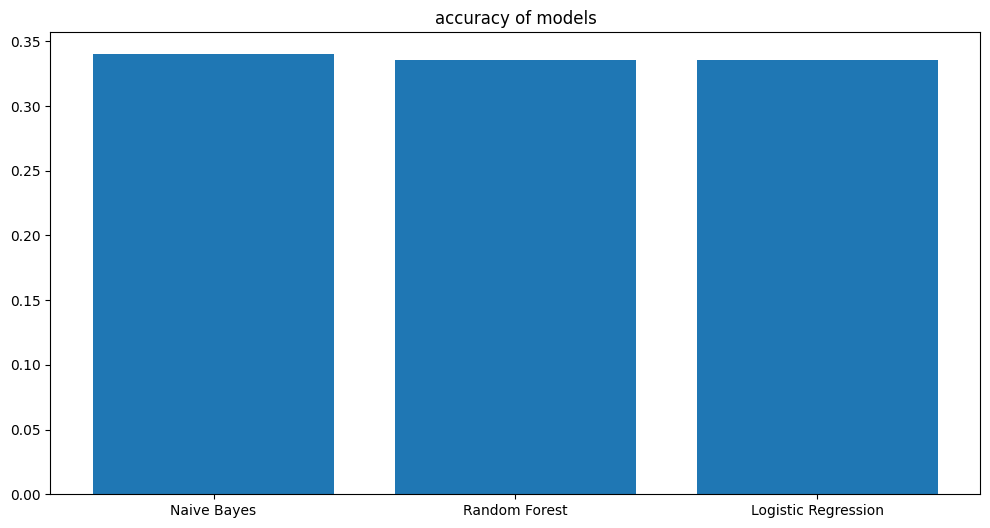

In [64]:


plot_bar_metrics("accuracy",metrics_dict)


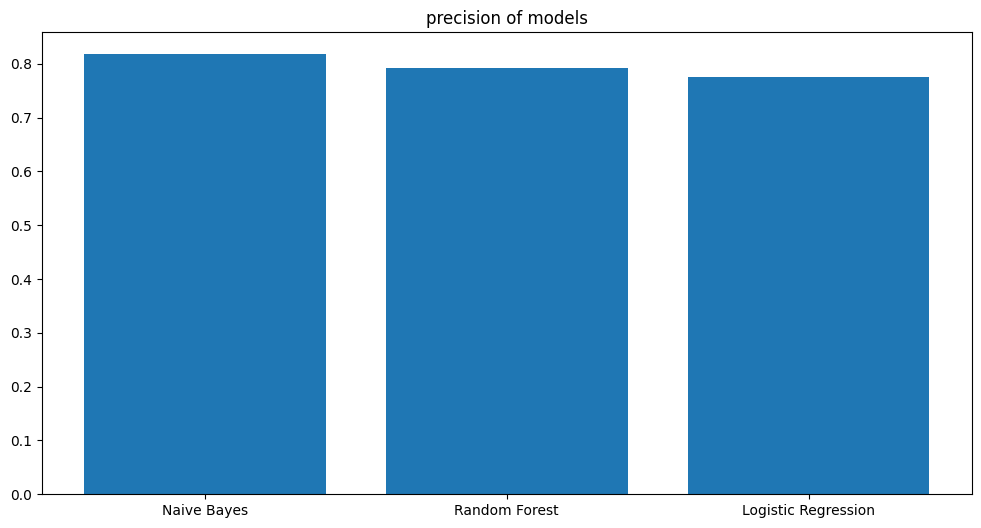

In [65]:

plot_bar_metrics("precision",metrics_dict)


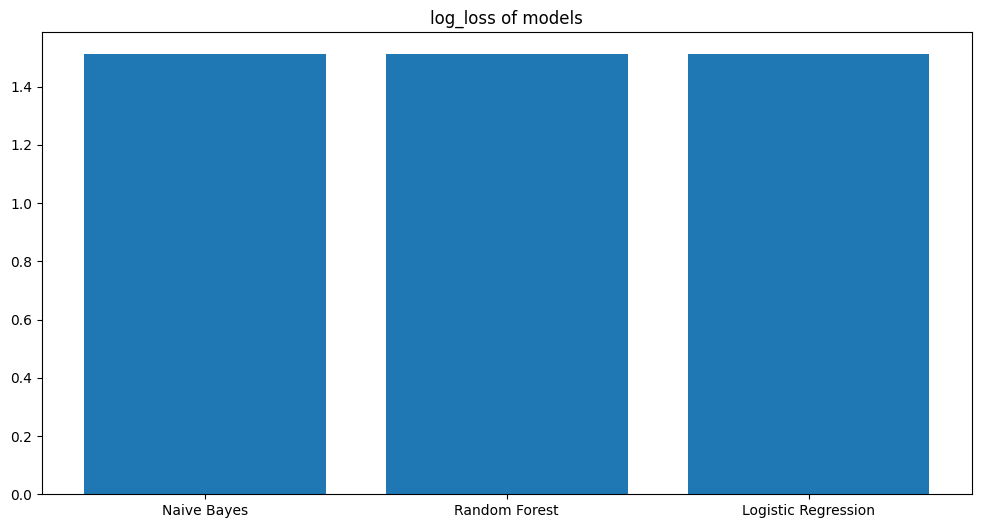

In [66]:

plot_bar_metrics("log_loss",metrics_dict)


Les modeles ont des performances similaires. Dans ce cas precis, il faut choisir le modele avec le sens qualitatif le plus coherent. Etant donne que nous sommes dans un contexte avec une quantite non binaire de labels, la Logistic Regression et le Naive Bayes restent moins explicatifs dans leurs decisions, contrairement au Random Forest. Dans cette etude, le Random Forest fait le plus de sens a la fois qualitativement et quantitativement, chaque arbre de la foret permettant de mieux capturer les differentes classes.


# Segmentation de tweets financiers

Dans cette partie, nous allons faire une segmentation de tweets financiers a l’aide de KMeans et BERTopic. L’objectif est de voir quels mots sont les plus utilises dans le monde financier et comment ils se regroupent dans l’espace.

## Outils:


In [67]:
def clean_tweet(text):
    if pd.isna(text):
        return ""
    text = str(text)
    text = re.sub(r"http\S+|www\.\S+", " ", text)
    text = re.sub(r"@\w+", " ", text)
    text = re.sub(r"#", "", text)
    text = re.sub(r"[^A-Za-zÀ-ÿ0-9\s$%]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text


## Importation de données:

In [71]:

df = import_tweets_table(bdd)

df["tweet_text"] = df["tweet_text"].astype(str).map(clean_tweet)
df = df[df["tweet_text"].str.len() > 5].drop_duplicates(subset=["tweet_text"]).reset_index(drop=True)

print("Cantité de tweets nettoyés:", len(df))

Cantité de tweets nettoyés: 17744


Dans cette partie, nous appliquons BERTopic afin de decouvrir les differents sujets presents dans les tweets financiers. Nous commençons par transformer la colonne "tweet_text" en une liste de textes, car BERTopic travaille directement avec ce format. Ensuite, nous definissons un vectorizer avec CountVectorizer. Celui-ci elimine les mots peu informatifs (stop words), prend en compte des groupes de 1 ou 2 mots (ngram) et conserve uniquement les mots apparaissant suffisamment souvent dans le dataset. Nous creons ensuite le modele BERTopic en lui passant ce vectorizer. Le modele est configure pour travailler en anglais, calculer les probabilites d’appartenance des tweets aux differents topics, imposer une taille minimale de 30 tweets par topic et limiter le nombre total de topics a 10. Le modele est ensuite entraine sur l’ensemble des tweets et attribue un topic a chaque tweet. Nous stockons ce resultat dans le dataframe. Enfin, nous affichons le nombre de topics detectes

In [72]:
docs = df["tweet_text"].tolist()

vectorizer_model = CountVectorizer(
    stop_words="english",
    ngram_range=(1, 2),
    min_df=5
)

topic_model = BERTopic(
    vectorizer_model=vectorizer_model,
    language="english",
    calculate_probabilities=True,
    min_topic_size=30,
    nr_topics=10
)

topics, probs = topic_model.fit_transform(docs)
df["bertopic_topic"] = topics

print("Cantité des topics detectés:", len(set(topics)) - (1 if -1 in set(topics) else 0))
print("Cantité des outliers (-1):", (df["bertopic_topic"] == -1).sum())

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 594.50it/s, Materializing param=pooler.dense.weight]                             
BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Cantité des topics detectés: 9
Cantité des outliers (-1): 5380


Puis on visualise la distance de chaque topic

In [ ]:
fig = topic_model.visualize_topics()
fig.show()

## Fonctions: 

La fonction vectoriser_tweets_tfidf permet de transformer les tweets en une matrice numerique. Elle prend le texte du dataframe et applique le TF-IDF afin de convertir chaque tweet en vecteur. Elle retourne le vectorizer et la matrice TF-IDF qui sera utilisee pour le clustering.

Ensuite, la fonction evaluer_kmeans permet de choisir le nombre optimal de clusters. Elle teste plusieurs valeurs de k (entre k_min et k_max) en appliquant KMeans a chaque fois, puis calcule le score de silhouette. Ce score mesure la qualite du clustering. La fonction retourne un tableau avec les scores ainsi que la meilleure valeur de k.

Enfin, la fonction appliquer_kmeans applique le modele KMeans avec le nombre de clusters choisi. Elle assigne un cluster a chaque tweet et ajoute cette information dans le dataframe. Elle retourne aussi le modele entraine ainsi qu’un tableau qui indique combien de tweets se trouvent dans chaque cluster.

In [ ]:

def vectoriser_tweets_tfidf(df,colonne_texte="tweet_text",stop_words="english",max_df=0.95,min_df=5,ngram_range=(1, 2)):
    vectoriseur_tfidf = TfidfVectorizer(
        stop_words=stop_words,
        max_df=max_df,
        min_df=min_df,
        ngram_range=ngram_range
    )

    matrice_tfidf = vectoriseur_tfidf.fit_transform(df[colonne_texte])
    return vectoriseur_tfidf, matrice_tfidf


def evaluer_kmeans(matrice_tfidf,k_min=4,k_max=12,random_state=42,n_init=10):
    valeurs_k = list(range(k_min, k_max + 1))
    resultats = []

    for k in valeurs_k:
        modele = KMeans(n_clusters=k, random_state=random_state, n_init=n_init)
        etiquettes = modele.fit_predict(matrice_tfidf)
        score = silhouette_score(matrice_tfidf, etiquettes)
        resultats.append((k, score))

    df_scores = pd.DataFrame(resultats, columns=["k", "score_silhouette"])
    meilleur_k = int(df_scores.sort_values("score_silhouette", ascending=False).iloc[0]["k"])
    return df_scores, meilleur_k


def appliquer_kmeans(df,matrice_tfidf,nombre_clusters,random_state=42,n_init=10,nom_colonne_cluster="cluster_kmeans"):
    df_resultat = df.copy()

    modele_kmeans = KMeans(
        n_clusters=nombre_clusters,
        random_state=random_state,
        n_init=n_init
    )

    df_resultat[nom_colonne_cluster] = modele_kmeans.fit_predict(matrice_tfidf)

    comptage_clusters = (
        df_resultat[nom_colonne_cluster]
        .value_counts()
        .rename_axis("cluster")
        .reset_index(name="nombre_tweets")
        .sort_values("nombre_tweets", ascending=False)
    )

    return df_resultat, modele_kmeans, comptage_clusters

## Application du modele KMeans et creation des clusters

In [ ]:
vectoriseur_tfidf, matrice_tfidf = vectoriser_tweets_tfidf(df, colonne_texte="tweet_text")

print("Forme de la matrice TF-IDF :", matrice_tfidf.shape)

df_scores, meilleur_k = evaluer_kmeans(matrice_tfidf, k_min=4, k_max=12)

df_kmeans, modele_kmeans, comptage_clusters = appliquer_kmeans(
    df, matrice_tfidf, nombre_clusters=meilleur_k, nom_colonne_cluster="cluster_kmeans"
)

print(meilleur_k)

Forme de la matrice TF-IDF : (17744, 8647)
12


## Conclution 

Dans cette segmentation a l’aide de deux modeles, le nombre de clusters ou de groupes est different, neanmoins dans le cadre de BERTopic le groupe le plus grand est celui lie aux stocks et aux earnings, ce qui reste tres interessant pour le modele de prediction de labels. Nous pouvons constater que KMeans, a l’aide du coefficient de silhouette, indique que 12 est la meilleure quantite de clusters, a la difference de BERTopic qui en detecte 8. Nous pouvons faire l’hypothese que le groupe tres large detecte par BERTopic est en realite subdivise par KMeans en plusieurs sous-groupes plus precis. Au final, pour notre site web, il est important d’avoir un modele simple mais capable d’expliquer cette partie speculative de la finance qui reste souvent negligee dans les variables quantitatives.